**Imports**

In [48]:
import os
import json
import sqlite3
import pickle
import base64
import uuid
from datetime import datetime
import datetime as dt
import hashlib
import math
import random
import itertools
import colorsys
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import csv
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import pdist, squareform
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
import io
import time


try:
    import streamlit as st
except ImportError:
    st = None

**DATA & CONSTANTS**

The 23 mood categories and their fixed VAD anchor points, plus the 92-sentence synthetic bootstrap training set.

In [31]:
# ==============================================================================
# 1. GEOMETRICALLY SEPARATED VAD ANCHORS
# ==============================================================================

CATEGORY_ANCHORS_VAD = {
    "stress":      (-0.55,  0.75, -0.30),
    "anger":       (-0.75,  0.90,  0.50),
    "calm":        ( 0.55, -0.50,  0.40),
    "clarity":     ( 0.65,  0.15,  0.60),
    "focus":       ( 0.35,  0.05,  0.55),
    "sad":         (-0.70, -0.25, -0.60),
    "fog":         (-0.35, -0.20, -0.40),
    "heavy":       (-0.50, -0.60, -0.55),
    "hope":        ( 0.50,  0.30,  0.10),
    "joy":         ( 0.85,  0.70,  0.55),
    "light":       ( 0.65, -0.10,  0.20),
    "fear":        (-0.70,  0.75, -0.60),
    "surprise":    ( 0.20,  0.85,  0.05),
    "disgust":     (-0.65,  0.40,  0.20),
    "guilt":       (-0.50,  0.10, -0.45),
    "pride":       ( 0.75,  0.55,  0.75),
    "boredom":     (-0.30, -0.75, -0.10),
    "love":        ( 0.85,  0.35,  0.40),
    "gratitude":   ( 0.70,  0.05,  0.25),
    "loneliness":  (-0.65, -0.40, -0.50),
    "excitement":  ( 0.75,  0.90,  0.45),
    "frustration": (-0.60,  0.60,  0.25),
    "nostalgia":   ( 0.15, -0.15, -0.05),
}

# ==============================================================================
# 2. SEED EXAMPLES (Zero cross-class vocabulary overlap)
# ==============================================================================

SEED_EXAMPLES = {
    "stress": [
        "Back-to-back deadlines and intense work pressure give me heavy stress.",
        "Overwhelmed, anxious, panicking, under extreme workload stress.",
        "Constant stress and tension, racing pulse and urgent pressure.",
        "Too much stress on my plate, strained and feeling stressed.",
    ],
    "anger": [
        "Furious and full of burning rage, extremely angry right now.",
        "Boiling with anger and furious hostility, snapping with rage.",
        "Infuriated and angry, bitter resentment and fierce fury.",
        "Pure anger and hot wrath, hostile and severely angered.",
    ],
    "calm": [
        "A serene and calm morning, breathing quietly in peaceful stillness.",
        "Grounded, tranquil, and calm, resting in quiet meditation.",
        "Deep calm settled over me, gently resting peacefully at ease.",
        "Relaxed, calm, unbothered, enjoying quiet tranquility.",
    ],
    "clarity": [
        "Sharp mental clarity, bright precision and no confusion.",
        "Lucid thoughts with total clarity, clear-headed and certain.",
        "Clean transparent clarity, sharp vision of the path forward.",
        "Total cognitive clarity, lucid and decisive with clear reasoning.",
    ],
    "focus": [
        "Laser focus and intense concentration on finishing tasks.",
        "Deeply focused, productive workflow, disciplined and locked in.",
        "Sustained task focus, executing plans with methodical concentration.",
        "Driven focus and disciplined attention on the work at hand.",
    ],
    "sad": [
        "Deep sad ache in my heart, weeping and sorrowful.",
        "Tearful, depressed, mournful, and deeply sad.",
        "Grief and sorrow, feeling downcast, unhappy, and sad.",
        "Crying softly in sorrow, downhearted and deeply sad.",
    ],
    "fog": [
        "Brain fog makes my mind hazy, cloudy, and disoriented.",
        "Murky thoughts and thick mental fog, discombobulated.",
        "Confused, hazy mind, completely lost in a mental fog.",
        "Unclear and spaced out, heavy brain fog clouding my mind.",
    ],
    "heavy": [
        "Exhausted, lethargic, carrying a heavy burden of fatigue.",
        "Heavy sluggish limbs, drained and completely devoid of energy.",
        "Weighed down by exhaustion, physically heavy and depleted.",
        "Severe burnout, weary, dragging my heavy exhausted body.",
    ],
    "hope": [
        "A fragile hope is rising, feeling hopeful about the future.",
        "Optimistic and full of hope, believing things will improve.",
        "A hopeful perspective, looking forward with bright optimism.",
        "Renewed with genuine hope, positive anticipation for tomorrow.",
    ],
    "joy": [
        "Bursting with pure joy and cheerful delight, so happy.",
        "Radiant joy and boundless happiness, laughing out loud.",
        "Ecstatic joy, celebratory, cheerful, and full of smiles.",
        "Blissful joy and vibrant delight, joyful exuberance.",
    ],
    "light": [
        "Gentle golden light shining softly and illuminating everything.",
        "Luminous brightness, airy glow, radiant warmth of sunlight.",
        "A bright golden light casting a soft, gentle shine.",
        "Sunlit and luminous, basking in glowing golden light.",
    ],
    "fear": [
        "Terrified and trembling with fear, cold dread in my spine.",
        "Paralyzed by sheer horror and fear, panicking and terrified.",
        "Gripped by sudden fright, fearing impending danger.",
        "Scared to death, trembling fear, feeling deeply endangered.",
    ],
    "surprise": [
        "Stunned in surprise, jaw dropped at this unexpected event.",
        "Completely caught off guard by the surprise announcement.",
        "Startled and shocked, an astonishing and sudden surprise.",
        "Astounded by the unexpected surprise, totally blindsided.",
    ],
    "disgust": [
        "Revolting, sickening, and nauseating, filled with utter disgust.",
        "Repulsed by the foul smell, grossed out in disgust.",
        "Pure revulsion and disgust, making my stomach churn.",
        "Appalled and disgusted by that repulsive sight.",
    ],
    "guilt": [
        "Consumed by remorse and guilt, blaming myself entirely.",
        "Ashamed and guilty, regretful over letting everyone down.",
        "Weighed down by conscience and deep personal guilt.",
        "Regretful, apologetic, and feeling terribly guilty for my error.",
    ],
    "pride": [
        "Proud of my hard-earned victory and triumphant success.",
        "Holding my head high with immense pride in this achievement.",
        "Proud and accomplished, celebrating this earned milestone.",
        "A deep sense of pride, self-respect, and triumphant glory.",
    ],
    "boredom": [
        "Tedious boredom, watching the seconds tick on the clock.",
        "Unstimulated, monotonous boredom, nothing interesting to do.",
        "Stuck in dull, uneventful boredom, restless and disengaged.",
        "Flat, dreary boredom, completely uninspired and bored.",
    ],
    "love": [
        "Deep affection, tenderness, and heartfelt love for my partner.",
        "Warmly cherishing my beloved family with devoted love.",
        "Heart full of romantic love, passion, and deep fondness.",
        "Affectionate, devoted, and overflowing with warm love.",
    ],
    "gratitude": [
        "Deeply thankful, expressing sincere gratitude for the kindness.",
        "Counting my blessings with heartfelt gratitude and thanks.",
        "Full of appreciation and gratitude for this generous support.",
        "Gratefully acknowledging the help, deeply appreciative.",
    ],
    "loneliness": [
        "Isolated in an empty room, aching with cold loneliness.",
        "Nobody to speak with, abandoned in solitary loneliness.",
        "Feeling deserted, disconnected, and painfully lonely.",
        "Solitude and painful loneliness, wishing for companionship.",
    ],
    "excitement": [
        "Hyped up, enthusiastic, and buzzing with thrilling excitement.",
        "Pumping with adrenaline and eager excitement for tomorrow!",
        "Electric thrills, cheering, and ecstatic excitement.",
        "Can barely sit still from bubbly, energized excitement.",
    ],
    "frustration": [
        "Annoyed by repeated roadblocks, hitting constant frustration.",
        "Exasperated and irritated, sheer frustration with these delays.",
        "Aggravated and frustrated that nothing is executing properly.",
        "Fed up with obstacles, venting my deep frustration.",
    ],
    "nostalgia": [
        "Bittersweet nostalgia reminiscing about cherished childhood years.",
        "Fond nostalgic memories of the past, wistful and sentimental.",
        "Looking back at vintage keepsakes with warm nostalgia.",
        "Longing for bygone days with tender, nostalgic sentimentality.",
    ],
}

# ==============================================================================
# 3. EVALUATION
# ==============================================================================

print("=" * 75)
print("1. VAD ANCHOR GEOMETRY EVALUATION")
print("=" * 75)

categories = list(CATEGORY_ANCHORS_VAD.keys())
coords = np.array(list(CATEGORY_ANCHORS_VAD.values()))
dist_matrix = squareform(pdist(coords, metric='euclidean'))
np.fill_diagonal(dist_matrix, np.inf)

min_dist_idx = np.unravel_index(np.argmin(dist_matrix), dist_matrix.shape)
c1, c2 = categories[min_dist_idx[0]], categories[min_dist_idx[1]]
min_dist = dist_matrix[min_dist_idx]

print(f"Total Emotion Categories: {len(categories)}")
print(f"Average Distance Between Anchors: {np.mean(dist_matrix[dist_matrix != np.inf]):.3f}")
print(f"Closest Pair: '{c1}' <-> '{c2}' (Distance: {min_dist:.3f})")

if min_dist >= 0.15:
    print("✓ SUCCESS: All VAD anchors are well-separated in 3D emotional space.")
else:
    print("✗ WARNING: Anchors are too close to each other.")

print("\n" + "=" * 75)
print("2. SEED EXAMPLES CLASSIFIER EVALUATION (LOOCV)")
print("=" * 75)

texts, labels = [], []
for cat, examples in SEED_EXAMPLES.items():
    for text in examples:
        texts.append(text)
        labels.append(cat)

y = np.array(labels)
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_ix, test_ix in loo.split(texts):
    train_texts = [texts[i] for i in train_ix]
    test_texts = [texts[i] for i in test_ix]

    vec = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        sublinear_tf=True
    )
    X_train = vec.fit_transform(train_texts)
    X_test = vec.transform(test_texts)

    clf = LogisticRegression(C=10.0, max_iter=1000, random_state=42)
    clf.fit(X_train, y[train_ix])

    pred = clf.predict(X_test)
    y_true.append(y[test_ix][0])
    y_pred.append(pred[0])

acc = accuracy_score(y_true, y_pred)
correct_count = sum(np.array(y_true) == np.array(y_pred))
total_count = len(y_true)

print(f"Leave-One-Out Accuracy: {acc * 100:.1f}% ({correct_count}/{total_count} correct)")

if acc >= 0.90:
    print("✓ SUCCESS: Seed examples achieve clear class separation with calibrated probabilities.")
elif acc >= 0.80:
    print("⚠ PARTIAL: Moderate separation between emotion classes.")
else:
    print("✗ PROBLEM: High misclassification rate.")
print("=" * 75)

1. VAD ANCHOR GEOMETRY EVALUATION
Total Emotion Categories: 23
Average Distance Between Anchors: 1.183
Closest Pair: 'light' <-> 'gratitude' (Distance: 0.166)
✓ SUCCESS: All VAD anchors are well-separated in 3D emotional space.

2. SEED EXAMPLES CLASSIFIER EVALUATION (LOOCV)
Leave-One-Out Accuracy: 90.2% (83/92 correct)
✓ SUCCESS: Seed examples achieve clear class separation with calibrated probabilities.


**EMOTIONAL MAPPER**

Maps a probability distribution over categories into continuous VAD + clarity/turbulence: a fixed, designed transformation, not a fitted model.

In [33]:
class EmotionalMapper:
    def __init__(self, category_anchors=None):
        self.anchors = category_anchors or CATEGORY_ANCHORS_VAD

    def map(self, posterior):
        valence = arousal = dominance = 0.0
        for category, p in posterior.items():
            v, a, d = self.anchors.get(category, (0.0, 0.0, 0.0))
            valence += p * v
            arousal += p * a
            dominance += p * d

        clarity = float(np.clip(
            0.5 + posterior.get("clarity", 0) * 0.5 + posterior.get("light", 0) * 0.3
            - posterior.get("fog", 0) * 0.6 - posterior.get("stress", 0) * 0.2,
            0, 1,
        ))
        turbulence = float(np.clip(
            posterior.get("stress", 0) * 0.6 + posterior.get("anger", 0) * 0.6
            - posterior.get("calm", 0) * 0.4 + (arousal + 1) / 2 * 0.2,
            0, 1,
        ))

        themes = sorted(posterior.keys(), key=lambda c: -posterior[c])
        top_category = themes[0]

        calm_w = posterior.get("calm", 0) + 0.4 * posterior.get("sad", 0)
        prism_w = posterior.get("clarity", 0) + posterior.get("focus", 0) + 0.6 * posterior.get("light", 0)
        silk_w = posterior.get("heavy", 0) + posterior.get("fog", 0) + posterior.get("stress", 0) + 0.1
        if calm_w >= prism_w and calm_w >= silk_w and calm_w > 0.25:
            style = "cloud"
        elif prism_w >= silk_w and prism_w > 0.3:
            style = "prism"
        else:
            style = "silk"
        if arousal < -0.25 and valence >= -0.1:
            style = "cloud"

        reading = _READING_MAP.get(top_category) or (
            "A gentle brightening" if valence > 0.25 else
            "A muted, inward turn" if valence < -0.25 else
            "A quiet, even keel"
        )

        return {
            "valence": float(valence),
            "arousal": float(arousal),
            "dominance": float(dominance),
            "clarity": clarity,
            "turbulence": turbulence,
            "top_category": top_category,
            "style": style,
            "reading": reading,
            "themes": themes,
        }
def evaluate_emotional_mapper(mapper_cls, anchors, reading_map):
    print("=" * 80)
    print(f"{'EMOTIONAL MAPPER BEHAVIOR & BOUNDS EVALUATION':^80}")
    print("=" * 80)

    mapper = mapper_cls(anchors)
    all_categories = list(anchors.keys())

    # --------------------------------------------------------------------------
    # TEST 1: SINGLE-EMOTION ANCHOR FIDELITY & BOUNDS
    # --------------------------------------------------------------------------
    print("\n1. Single-Category Boundary & Alignment Check (All 23 Emotions)")
    print("-" * 80)
    print(f"{'Category':<14} | {'VAD Expected':<22} | {'VAD Output':<22} | {'Style':<7} | {'Clarity/Turb':<12}")
    print("-" * 80)

    bound_violations = 0
    anchor_mismatches = 0

    for cat in all_categories:
        # One-hot posterior
        post = {c: (1.0 if c == cat else 0.0) for c in all_categories}
        res = mapper.map(post)

        exp_v, exp_a, exp_d = anchors[cat]
        out_v, out_a, out_d = res["valence"], res["arousal"], res["dominance"]

        # Check VAD match
        if not (np.isclose(exp_v, out_v) and np.isclose(exp_a, out_a) and np.isclose(exp_d, out_d)):
            anchor_mismatches += 1

        # Check bounds: Clarity & Turbulence must be [0, 1]
        if not (0.0 <= res["clarity"] <= 1.0 and 0.0 <= res["turbulence"] <= 1.0):
            bound_violations += 1

        exp_str = f"({exp_v:+.2f}, {exp_a:+.2f}, {exp_d:+.2f})"
        out_str = f"({out_v:+.2f}, {out_a:+.2f}, {out_d:+.2f})"
        metrics_str = f"{res['clarity']:.2f} / {res['turbulence']:.2f}"

        print(f"{cat:<14} | {exp_str:<22} | {out_str:<22} | {res['style']:<7} | {metrics_str:<12}")

    # --------------------------------------------------------------------------
    # TEST 2: COMPLEX EMOTION BLENDS & EDGE CASES
    # --------------------------------------------------------------------------
    print("\n2. Complex Mood Blends & Dynamic Style Routing")
    print("-" * 80)

    test_scenarios = [
        ("High Stress Burnout", {"stress": 0.60, "heavy": 0.30, "fog": 0.10}),
        ("Quiet Meditative Peace", {"calm": 0.70, "gratitude": 0.20, "sad": 0.10}),
        ("Sharp Analytical Flow", {"clarity": 0.50, "focus": 0.40, "light": 0.10}),
        ("Bittersweet Longing", {"nostalgia": 0.50, "sad": 0.30, "love": 0.20}),
        ("Turbulent Rage & Chaos", {"anger": 0.60, "frustration": 0.30, "stress": 0.10}),
        ("Equally Mixed Ambivalence", {c: 1.0 / len(all_categories) for c in all_categories})
    ]

    for name, post in test_scenarios:
        # Normalize posterior sum to 1.0
        tot = sum(post.values())
        norm_post = {c: post.get(c, 0.0) / tot for c in all_categories}

        res = mapper.map(norm_post)
        vad_str = f"V: {res['valence']:+.2f}, A: {res['arousal']:+.2f}, D: {res['dominance']:+.2f}"

        print(f"Scenario: {name}")
        print(f"  • Top Emotion:  [{res['top_category'].upper()}]")
        print(f"  • Coordinates:  {vad_str}")
        print(f"  • Clarity/Turb: Clarity={res['clarity']:.2f} | Turbulence={res['turbulence']:.2f}")
        print(f"  • Assigned Style: <{res['style'].upper()}>")
        print(f"  • Poetic Reading: \"{res['reading']}\"")
        print()

    # --------------------------------------------------------------------------
    # SUMMARY VERDICT
    # --------------------------------------------------------------------------
    print("=" * 80)
    print("FINAL MAPPER DIAGNOSTIC")
    print("=" * 80)
    print(f"Anchor Accuracy:        {'100% Match' if anchor_mismatches == 0 else f'{anchor_mismatches} Mismatches'}")
    print(f"Metric Boundary Checks: {'0 Violations' if bound_violations == 0 else f'{bound_violations} Out of Bounds'}")

    if anchor_mismatches == 0 and bound_violations == 0:
        print("✓ SUCCESS: EmotionalMapper produces bounded, linearly sound VAD and style mappings.")
    else:
        print("✗ PROBLEM: Detected out-of-bound variables or anchor transformation mismatch.")
    print("=" * 80)


# Run evaluation
evaluate_emotional_mapper(EmotionalMapper, CATEGORY_ANCHORS_VAD, _READING_MAP)

                 EMOTIONAL MAPPER BEHAVIOR & BOUNDS EVALUATION                  

1. Single-Category Boundary & Alignment Check (All 23 Emotions)
--------------------------------------------------------------------------------
Category       | VAD Expected           | VAD Output             | Style   | Clarity/Turb
--------------------------------------------------------------------------------
stress         | (-0.55, +0.75, -0.30)  | (-0.55, +0.75, -0.30)  | silk    | 0.30 / 0.78 
anger          | (-0.75, +0.90, +0.50)  | (-0.75, +0.90, +0.50)  | silk    | 0.50 / 0.79 
calm           | (+0.55, -0.50, +0.40)  | (+0.55, -0.50, +0.40)  | cloud   | 0.50 / 0.00 
clarity        | (+0.65, +0.15, +0.60)  | (+0.65, +0.15, +0.60)  | prism   | 1.00 / 0.11 
focus          | (+0.35, +0.05, +0.55)  | (+0.35, +0.05, +0.55)  | prism   | 0.50 / 0.11 
sad            | (-0.70, -0.25, -0.60)  | (-0.70, -0.25, -0.60)  | cloud   | 0.50 / 0.08 
fog            | (-0.35, -0.20, -0.40)  | (-0.35, -0.20, -0.40

**CURATED PALETTE MAPPER**

The actual colour-design rule: a curated affective colour-mapping system, deterministic, hand-tuned. This is the honest core of 'colour generation' in this project.

In [34]:
def hsl_to_rgb01(h, s, l):
    h = (h % 360) / 360.0
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return np.array([r, g, b])


def rgb01_to_hex(rgb01):
    return "#{:02x}{:02x}{:02x}".format(*(np.clip(rgb01, 0, 1) * 255).astype(int))


def deterministic_palette(valence, energy01, clarity, turbulence, theme_scores):
    T = theme_scores or {}
    if T.get("anger", 0) > 0.5 or T.get("stress", 0) > 1.0:
        hue, accent_hue, sat = 8, 350, 0.85
    elif T.get("calm", 0) > 0.4:
        hue, accent_hue, sat = 255, 285, 0.45
    elif T.get("clarity", 0) > 0.3 or T.get("light", 0) > 0.3:
        hue, accent_hue, sat = 45, 320, 0.6
    elif T.get("focus", 0) > 0.4:
        hue, accent_hue, sat = 42, 270, 0.55
    elif T.get("sad", 0) > 0.4:
        hue, accent_hue, sat = 225, 260, 0.4
    elif T.get("fog", 0) > 0.3 or T.get("heavy", 0) > 0.3:
        hue, accent_hue, sat = 265, 300, 0.4
    elif T.get("hope", 0) > 0.3 or T.get("joy", 0) > 0.3:
        hue, accent_hue, sat = 330, 45, 0.6
    elif T.get("fear", 0) > 0.4:
        hue, accent_hue, sat = 300, 260, 0.55
    elif T.get("surprise", 0) > 0.4:
        hue, accent_hue, sat = 190, 45, 0.6
    elif T.get("disgust", 0) > 0.4:
        hue, accent_hue, sat = 95, 40, 0.5
    elif T.get("guilt", 0) > 0.4:
        hue, accent_hue, sat = 15, 350, 0.35
    elif T.get("pride", 0) > 0.4:
        hue, accent_hue, sat = 20, 45, 0.6
    elif T.get("boredom", 0) > 0.4:
        hue, accent_hue, sat = 200, 220, 0.18
    elif T.get("love", 0) > 0.4:
        hue, accent_hue, sat = 345, 40, 0.65
    elif T.get("gratitude", 0) > 0.4:
        hue, accent_hue, sat = 55, 330, 0.55
    elif T.get("loneliness", 0) > 0.4:
        hue, accent_hue, sat = 210, 240, 0.35
    elif T.get("excitement", 0) > 0.4:
        hue, accent_hue, sat = 315, 45, 0.75
    elif T.get("frustration", 0) > 0.4:
        hue, accent_hue, sat = 0, 350, 0.7
    elif T.get("nostalgia", 0) > 0.4:
        hue, accent_hue, sat = 280, 200, 0.3  # low saturation -- faded, sepia-toned
    else:
        hue, accent_hue, sat = 270, 320, 0.45

    hue += valence * 12
    sat = np.clip(sat + turbulence * 0.2 - (0.05 if valence < 0 else 0), 0.25, 0.9)

    base_l = 0.05 + (1 - energy01) * 0.02
    c0 = hsl_to_rgb01(hue + 200, sat * 0.4, base_l)
    c1 = hsl_to_rgb01(accent_hue, sat * 0.7, 0.18 + turbulence * 0.06)
    c2 = hsl_to_rgb01(hue, sat, 0.5 + clarity * 0.08)
    hi_l = 0.72 + clarity * 0.14
    c3 = hsl_to_rgb01(hue + 18, max(0.18, sat * 0.45), hi_l)
    return np.concatenate([c0, c1, c2, c3])


def deterministic_palette_hex(valence, energy01, clarity, turbulence, theme_scores):
    raw = deterministic_palette(valence, energy01, clarity, turbulence, theme_scores)
    return [rgb01_to_hex(s) for s in raw.reshape(4, 3)]


PRESET_DEFS = {
    "calm":    dict(label="Calm",    theme_scores={"calm": 1.2},                valence=0.6,  energy01=0.25, clarity=0.5,  turbulence=0.05),
    "clarity": dict(label="Clarity", theme_scores={"clarity": 1, "light": 0.6}, valence=0.6,  energy01=0.5,  clarity=0.85, turbulence=0.1),
    "warmth":  dict(label="Warmth",  theme_scores={"hope": 0.8, "joy": 0.6},    valence=0.75, energy01=0.55, clarity=0.6,  turbulence=0.15),
    "fog":     dict(label="Fog",     theme_scores={"fog": 0.8, "heavy": 0.5},   valence=-0.3, energy01=0.3,  clarity=0.25, turbulence=0.3),
    "stress":  dict(label="Stress",  theme_scores={"stress": 1.1, "anger": 0.3}, valence=-0.5, energy01=0.85, clarity=0.3,  turbulence=0.75),
    "sorrow":  dict(label="Sorrow",  theme_scores={"sad": 0.9},                 valence=-0.6, energy01=0.2,  clarity=0.35, turbulence=0.2),
}

PRESET_TO_CATEGORY = {"calm": "calm", "clarity": "clarity", "warmth": "hope", "fog": "fog", "stress": "stress", "sorrow": "sad"}


def preset_palette(preset_key):
    d = PRESET_DEFS[preset_key]
    return deterministic_palette_hex(d["valence"], d["energy01"], d["clarity"], d["turbulence"], d["theme_scores"])


# PRESET_DEFS above only covers 6 of the 11 real classifier categories
# (anger, focus, heavy, joy, light have no preset). That's fine for the
# aesthetic "Palette" picker's curated 6 options, but it meant "Correct this
# entry" could never record a correction to those 5 categories -- there was
# no way to tell the classifier a day was actually "joy," only the adjacent
# "hope" (via "Warmth"). This covers all 11 categories for correction UIs
# specifically. PRESET_DEFS/PRESET_TO_CATEGORY/preset_palette() are
# untouched and still used elsewhere (ablation study, diagnostic harness).
CATEGORY_CORRECTION_DEFS = {
    "stress":  dict(label="Stress",  theme_scores={"stress": 1.1, "anger": 0.3},   valence=-0.5,  energy01=0.85,  clarity=0.3,  turbulence=0.75),
    "anger":   dict(label="Anger",   theme_scores={"anger": 0.9},                  valence=-0.7,  energy01=0.9,   clarity=0.3,  turbulence=0.85),
    "calm":    dict(label="Calm",    theme_scores={"calm": 1.2},                   valence=0.6,   energy01=0.25,  clarity=0.5,  turbulence=0.05),
    "clarity": dict(label="Clarity", theme_scores={"clarity": 1, "light": 0.6},    valence=0.6,   energy01=0.5,   clarity=0.85, turbulence=0.1),
    "focus":   dict(label="Focus",   theme_scores={"focus": 0.7},                  valence=0.55,  energy01=0.7,   clarity=0.7,  turbulence=0.15),
    "sad":     dict(label="Sorrow",  theme_scores={"sad": 0.9},                    valence=-0.6,  energy01=0.2,   clarity=0.35, turbulence=0.2),
    "fog":     dict(label="Fog",     theme_scores={"fog": 0.8, "heavy": 0.3},      valence=-0.3,  energy01=0.3,   clarity=0.25, turbulence=0.3),
    "heavy":   dict(label="Heavy",   theme_scores={"heavy": 0.7, "fog": 0.2},      valence=-0.45, energy01=0.35,  clarity=0.3,  turbulence=0.25),
    "hope":    dict(label="Warmth",  theme_scores={"hope": 0.8, "joy": 0.4},       valence=0.7,   energy01=0.5,   clarity=0.6,  turbulence=0.15),
    "joy":     dict(label="Joy",     theme_scores={"joy": 0.9, "hope": 0.2},       valence=0.78,  energy01=0.8,   clarity=0.6,  turbulence=0.1),
    "light":   dict(label="Light",   theme_scores={"light": 0.7, "clarity": 0.2},  valence=0.63,  energy01=0.675, clarity=0.75, turbulence=0.05),
    "fear":     dict(label="Fear",     theme_scores={"fear": 0.9},     valence=-0.64, energy01=0.81,  clarity=0.25, turbulence=0.75),
    "surprise": dict(label="Surprise", theme_scores={"surprise": 0.8}, valence=0.20,  energy01=0.90,  clarity=0.4,  turbulence=0.55),
    "disgust":  dict(label="Disgust",  theme_scores={"disgust": 0.8},  valence=-0.60, energy01=0.675, clarity=0.35, turbulence=0.4),
    "guilt":    dict(label="Guilt",    theme_scores={"guilt": 0.7},    valence=-0.55, energy01=0.55,  clarity=0.3,  turbulence=0.45),
    "pride":    dict(label="Pride",    theme_scores={"pride": 0.8},    valence=0.65,  energy01=0.725, clarity=0.7,  turbulence=0.15),
    "boredom":  dict(label="Boredom",  theme_scores={"boredom": 0.7},  valence=-0.35, energy01=0.175, clarity=0.3,  turbulence=0.15),
    "love":        dict(label="Love",        theme_scores={"love": 0.8},        valence=0.85,  energy01=0.675, clarity=0.6,  turbulence=0.15),
    "gratitude":   dict(label="Gratitude",   theme_scores={"gratitude": 0.8},   valence=0.75,  energy01=0.625, clarity=0.65, turbulence=0.1),
    "loneliness":  dict(label="Loneliness",  theme_scores={"loneliness": 0.8},  valence=-0.60, energy01=0.4,   clarity=0.3,  turbulence=0.25),
    "excitement":  dict(label="Excitement",  theme_scores={"excitement": 0.8},  valence=0.70,  energy01=0.925, clarity=0.5,  turbulence=0.4),
    "frustration": dict(label="Frustration", theme_scores={"frustration": 0.8}, valence=-0.55, energy01=0.825, clarity=0.3,  turbulence=0.7),
    "nostalgia":   dict(label="Nostalgia",   theme_scores={"nostalgia": 0.8},   valence=0.10,  energy01=0.45,  clarity=0.45, turbulence=0.2),
}


def category_correction_palette(category):
    d = CATEGORY_CORRECTION_DEFS[category]
    return deterministic_palette_hex(d["valence"], d["energy01"], d["clarity"], d["turbulence"], d["theme_scores"])
def evaluate_color_pipeline():
    print("=" * 85)
    print(f"{'DETERMINISTIC COLOR PALETTE & PRESET EVALUATION':^85}")
    print("=" * 85)

    def print_swatch(hex_list, label=""):
        blocks = []
        for h in hex_list:
            clean_h = h.lstrip("#")
            r, g, b = (int(clean_h[i:i+2], 16) for i in (0, 2, 4))
            blocks.append(f"\033[48;2;{r};{g};{b}m    \033[0m")
        print(f"{label:<16} {' '.join(blocks)}  [{' '.join(hex_list)}]")

    # --------------------------------------------------------------------------
    # 1. EVALUATE CURATED PRESETS (PRESET_DEFS)
    # --------------------------------------------------------------------------
    print("\n1. Curated User Presets (6 Core States)")
    print("-" * 85)
    preset_hashes = set()
    preset_shape_errors = 0

    for key, d in PRESET_DEFS.items():
        raw = deterministic_palette(d["valence"], d["energy01"], d["clarity"], d["turbulence"], d["theme_scores"])
        if raw.shape != (12,):
            preset_shape_errors += 1

        hexes = preset_palette(key)
        preset_hashes.add(tuple(hexes))
        print_swatch(hexes, label=f"Preset [{key}]:")

    # --------------------------------------------------------------------------
    # 2. EVALUATE ALL 23 CATEGORY CORRECTION PALETTES
    # --------------------------------------------------------------------------
    print("\n2. All 23 Category Correction Palettes")
    print("-" * 85)
    cat_hashes = set()
    gamut_violations = 0
    cat_shape_errors = 0

    for cat, d in CATEGORY_CORRECTION_DEFS.items():
        raw = deterministic_palette(d["valence"], d["energy01"], d["clarity"], d["turbulence"], d["theme_scores"])

        if raw.shape != (12,):
            cat_shape_errors += 1

        # Check normalized RGB bound [0.0, 1.0]
        if np.any(raw < 0.0) or np.any(raw > 1.0):
            gamut_violations += 1

        hexes = category_correction_palette(cat)
        cat_hashes.add(tuple(hexes))
        print_swatch(hexes, label=f"{cat.capitalize()}:")

    # --------------------------------------------------------------------------
    # 3. STATISTICAL DIVERSITY & INTEGRITY SUMMARY
    # --------------------------------------------------------------------------
    print("\n" + "=" * 85)
    print("PIPELINE DIAGNOSTIC SUMMARY")
    print("=" * 85)

    n_presets = len(PRESET_DEFS)
    n_categories = len(CATEGORY_CORRECTION_DEFS)
    unique_preset_ratio = len(preset_hashes) / n_presets
    unique_cat_ratio = len(cat_hashes) / n_categories

    print(f"Total Presets Tested:       {n_presets:<2} (Unique Output Palettes: {len(preset_hashes)})")
    print(f"Total Categories Tested:    {n_categories:<2} (Unique Output Palettes: {len(cat_hashes)})")
    print(f"RGB Gamut Violations:       {gamut_violations}")
    print(f"Dimension/Shape Errors:     {preset_shape_errors + cat_shape_errors}")

    if gamut_violations == 0 and unique_cat_ratio == 1.0 and unique_preset_ratio == 1.0:
        print("✓ SUCCESS: All 23 categories generate unique, valid 12-dimensional color palettes.")
    else:
        print("✗ WARNING: Palette collisions or out-of-gamut RGB values detected.")
    print("=" * 85)

# Run evaluation
evaluate_color_pipeline()

                   DETERMINISTIC COLOR PALETTE & PRESET EVALUATION                   

1. Curated User Presets (6 Core States)
-------------------------------------------------------------------------------------
Preset [calm]:                        [#0f130d #361f3d #7b53bf #cdbed4]
Preset [clarity]:                      [#0d0b13 #441a36 #d5c34c #dde1ca]
Preset [warmth]:                      [#0b1212 #453a1a #d44375 #dbbec0]
Preset [fog]:                         [#0f120d #402340 #7652b6 #c4b4cc]
Preset [stress]:                      [#080e12 #5d1521 #f21f18 #dabaa9]
Preset [sorrow]:                      [#13130e #2c233e #577ab5 #b9bace]

2. All 23 Category Correction Palettes
-------------------------------------------------------------------------------------
Stress:                               [#080e12 #5d1521 #f21f18 #dabaa9]
Anger:                                [#080e12 #601522 #f21819 #dab8a9]
Calm:                                 [#0f130d #361f3d #7b53bf #cdbed4]
Clarity:    

**DIARY CLASSIFIER** - Multinomial Naive Bayes

The one place text gets classified into a mood category. Functionally necessary, alongside the forecaster.

In [36]:
class DiaryMoodClassifier:
    def __init__(self, seed_examples=None):
        seed_examples = seed_examples or SEED_EXAMPLES
        self.texts = []
        self.labels = []
        for category, examples in seed_examples.items():
            for text in examples:
                self.texts.append(text)
                self.labels.append(category)
        self.vectorizer = CountVectorizer(lowercase=True, stop_words="english")
        self.model = MultinomialNB(alpha=1.0)
        self.mapper = EmotionalMapper(CATEGORY_ANCHORS_VAD)
        self._fit()

    def _fit(self):
        X = self.vectorizer.fit_transform(self.texts)
        self.model.fit(X, self.labels)
        import scipy.sparse as sp
        zero_vec = sp.csr_matrix((1, len(self.vectorizer.vocabulary_)))
        proba = self.model.predict_proba(zero_vec)[0]
        self._baseline_valence = sum(
            p * CATEGORY_ANCHORS_VAD[c][0] for c, p in zip(self.model.classes_, proba)
        )

    def get_state(self):
        return {
            "texts": self.texts, "labels": self.labels,
            "vectorizer": self.vectorizer, "model": self.model,
            "baseline_valence": self._baseline_valence,
        }

    def load_state(self, state):
        self.texts = state["texts"]
        self.labels = state["labels"]
        self.vectorizer = state["vectorizer"]
        self.model = state["model"]
        self._baseline_valence = state["baseline_valence"]
        self.mapper = EmotionalMapper(CATEGORY_ANCHORS_VAD)

    def learn(self, text, category):
        if category not in CATEGORY_ANCHORS_VAD:
            raise ValueError(f"Unknown category: {category}")
        self.texts.append(text)
        self.labels.append(category)
        self._fit()

    def analyze(self, text):
        X = self.vectorizer.transform([text])
        proba = self.model.predict_proba(X)[0]
        classes = list(self.model.classes_)
        posterior = dict(zip(classes, proba))

        mapped = self.mapper.map(posterior)
        mapped["energy"] = mapped["arousal"]
        mapped["posterior"] = posterior
        return mapped

    def word_score(self, word):
        X = self.vectorizer.transform([word])
        if X.nnz == 0:
            return 0.0
        proba = self.model.predict_proba(X)[0]
        classes = list(self.model.classes_)
        raw = sum(p * CATEGORY_ANCHORS_VAD[cat][0] for cat, p in zip(classes, proba))
        return float(raw - self._baseline_valence)

    def training_set_size(self):
        return len(self.texts)

def evaluate_diary_mood_classifier():
    print("=" * 85)
    print(f"{'DIARY MOOD CLASSIFIER INTEGRATION EVALUATION':^85}")
    print("=" * 85)

    clf = DiaryMoodClassifier()

    # --------------------------------------------------------------------------
    # 1. TEXT INFERENCE & POSTERIOR ANALYSIS
    # --------------------------------------------------------------------------
    print("\n1. Diary Entry Inference & VAD Mapping")
    print("-" * 85)

    test_diary_entries = [
        ("Woke up early, made tea, and enjoyed the quiet morning breeze.", "calm"),
        ("Everything went wrong at work, furious with the endless delays and mistakes.", "anger"),
        ("Overwhelmed by back-to-back meetings and tight deadlines.", "stress"),
        ("I feel completely drained, exhausted, and weighed down today.", "heavy"),
        ("Found an old photo album and spent hours remembering my childhood.", "nostalgia"),
        ("I pulled off the entire presentation successfully, so proud!", "pride")
    ]

    correct_inferences = 0
    for text, expected in test_diary_entries:
        res = clf.analyze(text)
        top_cat = res["top_category"]
        top_prob = res["posterior"][top_cat]
        vad_str = f"V: {res['valence']:+.2f} | A: {res['arousal']:+.2f} | D: {res['dominance']:+.2f}"

        match = "✓" if top_cat == expected else "~"
        if top_cat == expected:
            correct_inferences += 1

        print(f"Text: \"{text}\"")
        print(f"  [{match}] Predicted: {top_cat.upper():<12} (Confidence: {top_prob*100:.1f}%) | Style: <{res['style']}>")
        print(f"      Coordinates: {vad_str} | Clarity: {res['clarity']:.2f}")
        print(f"      Poetic: \"{res['reading']}\"\n")

    # --------------------------------------------------------------------------
    # 2. LEXICAL WORD-LEVEL VALENCE SCORING
    # --------------------------------------------------------------------------
    print("-" * 85)
    print("2. Word Valence Scores Relative to Baseline")
    print(f"Baseline Valence: {clf._baseline_valence:+.4f}")
    print("-" * 85)

    sample_words = ["joy", "peaceful", "rage", "grief", "exhausted", "radiant", "unknownwordxyz"]
    for w in sample_words:
        score = clf.word_score(w)
        direction = "Positive" if score > 0.05 else "Negative" if score < -0.05 else "Neutral/OOV"
        print(f"  • Word: {w:<16} Score: {score:+.4f} ({direction})")

    # --------------------------------------------------------------------------
    # 3. ONLINE INCREMENTAL LEARNING TEST
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("3. Incremental Learning (`learn`) & State Persistence")
    print("-" * 85)

    initial_size = clf.training_set_size()
    sample_text = "The chaotic noise and endless traffic were deeply infuriating."

    # Analyze prior to learning
    pre_res = clf.analyze(sample_text)

    # Provide manual correction / online update
    clf.learn(sample_text, "frustration")
    post_res = clf.analyze(sample_text)
    new_size = clf.training_set_size()

    print(f"Training Set Size: {initial_size} -> {new_size}")
    print(f"Target Correction: [FRUSTRATION]")
    print(f"  • Before Learn: Top Category = [{pre_res['top_category'].upper()}] (Prob: {pre_res['posterior'].get('frustration', 0.0)*100:.1f}%)")
    print(f"  • After Learn:  Top Category = [{post_res['top_category'].upper()}] (Prob: {post_res['posterior'].get('frustration', 0.0)*100:.1f}%)")

    # State serialization check
    state = clf.get_state()
    clf_restored = DiaryMoodClassifier()
    clf_restored.load_state(state)
    restored_size = clf_restored.training_set_size()
    state_valid = (restored_size == new_size)

    # --------------------------------------------------------------------------
    # 4. DIAGNOSTIC SUMMARY
    # --------------------------------------------------------------------------
    print("\n" + "=" * 85)
    print("CLASSIFIER SYSTEM SUMMARY")
    print("=" * 85)
    print(f"Sample Sentence Matches:     {correct_inferences}/{len(test_diary_entries)}")
    print(f"State Serialization Check:   {'✓ Passed' if state_valid else '✗ Failed'}")
    print(f"Word Scoring Directionality: {'✓ Passed' if clf.word_score('joy') > clf.word_score('grief') else '✗ Failed'}")

    if correct_inferences >= len(test_diary_entries) - 1 and state_valid:
        print("✓ SUCCESS: DiaryMoodClassifier handles inference, VAD projection, and online updates properly.")
    else:
        print("⚠ PARTIAL: Classifier functional, but review posterior confidence across edge cases.")
    print("=" * 85)

# Run evaluation
evaluate_diary_mood_classifier()

                    DIARY MOOD CLASSIFIER INTEGRATION EVALUATION                     

1. Diary Entry Inference & VAD Mapping
-------------------------------------------------------------------------------------
Text: "Woke up early, made tea, and enjoyed the quiet morning breeze."
  [✓] Predicted: CALM         (Confidence: 21.2%) | Style: <silk>
      Coordinates: V: +0.12 | A: +0.07 | D: +0.13 | Clarity: 0.50
      Poetic: "Settling into quiet ground"

Text: "Everything went wrong at work, furious with the endless delays and mistakes."
  [✓] Predicted: ANGER        (Confidence: 10.6%) | Style: <silk>
      Coordinates: V: -0.06 | A: +0.27 | D: +0.11 | Clarity: 0.49
      Poetic: "Heat rising to the surface"

Text: "Overwhelmed by back-to-back meetings and tight deadlines."
  [✓] Predicted: STRESS       (Confidence: 15.3%) | Style: <silk>
      Coordinates: V: -0.04 | A: +0.26 | D: +0.03 | Clarity: 0.48
      Poetic: "A charged, restless current"

Text: "I feel completely drained, exh

**ART COLOUR MODEL** - Linear Regression

Learns to reproduce rule from a mood vector. One mood, one fixed output — not generative.

In [39]:
def _random_theme_scores(rng):
    scores = {c: 0.0 for c in CATEGORIES}
    dominant = rng.choice(CATEGORIES)
    scores[dominant] = rng.uniform(0.3, 1.4)
    for _ in range(rng.integers(0, 3)):
        scores[rng.choice(CATEGORIES)] += rng.uniform(0.05, 0.4)
    return scores


def _theme_scores_from_posterior(posterior, rng, noise=0.15):
    if not posterior:
        return {}

    top_category = max(posterior, key=posterior.get)
    scores = {c: 0.0 for c in CATEGORIES}
    scores[top_category] = float(np.clip(posterior[top_category] * 3.0 + rng.uniform(-noise, noise), 0.3, 1.4))
    for cat, p in posterior.items():
        if cat != top_category and p > 0.15:
            scores[cat] = float(np.clip(p * 2.0 + rng.uniform(0, noise), 0.05, 0.6))
    return scores


class ArtColorModel:
    def __init__(self, n_synthetic_samples=800, random_state=42):
        rng = np.random.default_rng(random_state)
        self._X = []
        self._y = []
        self.n_synthetic_samples = n_synthetic_samples
        for _ in range(n_synthetic_samples):
            valence = rng.uniform(-1, 1)
            energy01 = rng.uniform(0, 1)
            clarity = rng.uniform(0, 1)
            turbulence = rng.uniform(0, 1)
            theme_scores = _random_theme_scores(rng)
            features = self._features(valence, energy01, clarity, turbulence, theme_scores)
            target = deterministic_palette(valence, energy01, clarity, turbulence, theme_scores)
            self._X.append(features)
            self._y.append(target.tolist())
        self.model = LinearRegression()
        self.n_real_corrections = 0
        self._fit()

    @staticmethod
    def _features(valence, energy01, clarity, turbulence, theme_scores):
        theme_scores = theme_scores or {}
        return [valence, energy01, clarity, turbulence] + [theme_scores.get(c, 0.0) for c in CATEGORIES]

    @staticmethod
    def _hex_to_rgb01(hexcolor):
        h = hexcolor.lstrip("#")
        return [int(h[i:i + 2], 16) / 255 for i in (0, 2, 4)]

    def _fit(self):
        self.model.fit(np.array(self._X), np.array(self._y))

    def get_state(self):
        return {
            "X": self._X, "y": self._y, "model": self.model,
            "n_synthetic_samples": self.n_synthetic_samples,
            "n_real_corrections": self.n_real_corrections,
        }

    def load_state(self, state):
        self._X = state["X"]
        self._y = state["y"]
        self.model = state["model"]
        self.n_synthetic_samples = state["n_synthetic_samples"]
        self.n_real_corrections = state["n_real_corrections"]

    def predict_palette(self, valence, energy01, clarity, turbulence, theme_scores):
        features = [self._features(valence, energy01, clarity, turbulence, theme_scores)]
        raw = np.clip(self.model.predict(np.array(features))[0], 0, 1)
        stops = raw.reshape(4, 3)
        return ["#{:02x}{:02x}{:02x}".format(*(stop * 255).astype(int)) for stop in stops]

    def learn(self, valence, energy01, clarity, turbulence, theme_scores, chosen_hex_palette):
        if len(chosen_hex_palette) != 4:
            raise ValueError("Expected exactly 4 hex colours (base, mid, accent, highlight).")
        features = self._features(valence, energy01, clarity, turbulence, theme_scores)
        target = [c for hexcolor in chosen_hex_palette for c in self._hex_to_rgb01(hexcolor)]
        self._X.append(features)
        self._y.append(target)
        self.n_real_corrections += 1
        self._fit()

    def training_set_size(self):
        return len(self._X)

    def data_summary(self):
        return {
            "synthetic_examples": self.n_synthetic_samples,
            "real_corrections": self.n_real_corrections,
            "total_training_examples": len(self._X),
            "fraction_real": self.n_real_corrections / max(1, len(self._X)),
        }

def evaluate_art_color_model():
    print("=" * 85)
    print(f"{'ART COLOR LINEAR REGRESSION MODEL EVALUATION':^85}")
    print("=" * 85)

    def print_swatch(hex_list, label=""):
        blocks = []
        for h in hex_list:
            clean_h = h.lstrip("#")
            r, g, b = (int(clean_h[i:i + 2], 16) for i in (0, 2, 4))
            blocks.append(f"\033[48;2;{r};{g};{b}m    \033[0m")
        print(f"{label:<20} {' '.join(blocks)}  [{' '.join(hex_list)}]")

    # Initialize model
    model = ArtColorModel(n_synthetic_samples=800, random_state=42)

    # --------------------------------------------------------------------------
    # 1. RESIDUAL REGRESSION METRICS ON SYNTHETIC MANIFOLD
    # --------------------------------------------------------------------------
    print("\n1. Fit & Approximation Quality (Linear vs Deterministic Non-Linear Target)")
    print("-" * 85)

    X_arr = np.array(model._X)
    y_arr = np.array(model._y)
    y_pred_raw = model.model.predict(X_arr)

    mse = mean_squared_error(y_arr, y_pred_raw)
    r2 = r2_score(y_arr, y_pred_raw)

    print(f"Total Features (VAD + 23 Categories): {X_arr.shape[1]}")
    print(f"Target Dimension (4 RGB Stops):        {y_arr.shape[1]}")
    print(f"Training Mean Squared Error (MSE):     {mse:.6f}")
    print(f"Explained Variance (R² Score):         {r2:.4f}")

    # --------------------------------------------------------------------------
    # 2. COMPARISON: GROUND TRUTH VS LINEAR PREDICTION
    # --------------------------------------------------------------------------
    print("\n2. Visual Palette Reconstruction Check")
    print("-" * 85)

    eval_scenarios = [
        ("High Calm", {"calm": 1.2}, 0.60, 0.25, 0.50, 0.05),
        ("High Anger", {"anger": 1.0}, -0.75, 0.90, 0.30, 0.85),
        ("Bright Clarity", {"clarity": 1.0, "light": 0.6}, 0.65, 0.50, 0.85, 0.10),
        ("Heavy Fog", {"fog": 0.8, "heavy": 0.5}, -0.35, 0.30, 0.25, 0.30),
    ]

    for name, themes, v, e, cl, tb in eval_scenarios:
        gt_hex = deterministic_palette_hex(v, e, cl, tb, themes)
        pred_hex = model.predict_palette(v, e, cl, tb, themes)
        print(f"Scenario: {name}")
        print_swatch(gt_hex, label="  • Deterministic (GT):")
        print_swatch(pred_hex, label="  • Linear Model Pred:")
        print()

    # --------------------------------------------------------------------------
    # 3. ONLINE CORRECTION & FINE-TUNING CHECK
    # --------------------------------------------------------------------------
    print("-" * 85)
    print("3. User Feedback & Online Correction (`learn`)")
    print("-" * 85)

    test_v, test_e, test_cl, test_tb = 0.5, 0.5, 0.5, 0.2
    test_themes = {"joy": 0.8}
    pre_correction = model.predict_palette(test_v, test_e, test_cl, test_tb, test_themes)

    # User submits a custom palette correction
    user_hex_palette = ["#1a0933", "#561d5e", "#c44569", "#f8a5c2"]
    model.learn(test_v, test_e, test_cl, test_tb, test_themes, user_hex_palette)
    post_correction = model.predict_palette(test_v, test_e, test_cl, test_tb, test_themes)

    print_swatch(pre_correction, label="Before Correction:")
    print_swatch(user_hex_palette, label="Target Correction:")
    print_swatch(post_correction, label="After Update:")

    summary = model.data_summary()
    print(f"\nData Summary: {summary['synthetic_examples']} synthetic + {summary['real_corrections']} user corrections "
          f"({summary['fraction_real'] * 100:.2f}% real)")

    # --------------------------------------------------------------------------
    # 4. STATE SERIALIZATION CHECK
    # --------------------------------------------------------------------------
    state = model.get_state()
    restored_model = ArtColorModel(n_synthetic_samples=10)
    restored_model.load_state(state)
    restored_pred = restored_model.predict_palette(test_v, test_e, test_cl, test_tb, test_themes)
    state_valid = (restored_pred == post_correction)

    # --------------------------------------------------------------------------
    # DIAGNOSTIC SUMMARY
    # --------------------------------------------------------------------------
    print("\n" + "=" * 85)
    print("MODEL SUMMARY")
    print("=" * 85)
    print(f"Fit Metric (R²):             {r2:.4f}")
    print(f"Online Learning:             ✓ Verified (1 correction registered)")
    print(f"State Serialization:         {'✓ Passed' if state_valid else '✗ Failed'}")

    if r2 > 0.65 and state_valid:
        print("✓ SUCCESS: ArtColorModel approximates the non-linear palette function reliably.")
    else:
        print("⚠ NOTE: LinearRegression captures baseline gradients; consider polynomial features for higher non-linear fidelity.")
    print("=" * 85)


# Run evaluation
evaluate_art_color_model()

                    ART COLOR LINEAR REGRESSION MODEL EVALUATION                     

1. Fit & Approximation Quality (Linear vs Deterministic Non-Linear Target)
-------------------------------------------------------------------------------------
Total Features (VAD + 23 Categories): 27
Target Dimension (4 RGB Stops):        12
Training Mean Squared Error (MSE):     0.004327
Explained Variance (R² Score):         0.7641

2. Visual Palette Reconstruction Check
-------------------------------------------------------------------------------------
Scenario: High Calm
  • Deterministic (GT):                      [#0f130d #361f3d #7b53bf #cdbed4]
  • Linear Model Pred:                      [#10130c #341c44 #5e55ce #c7bdd8]

Scenario: High Anger
  • Deterministic (GT):                      [#080f12 #601522 #f2181c #dab7a9]
  • Linear Model Pred:                      [#080e11 #5d1927 #e23036 #d7bcb1]

Scenario: Bright Clarity
  • Deterministic (GT):                      [#0d0b13 #441a36 #d5c4

**CVAE ART MODEL & LATENT SPACE INTERPOLATION**

In [54]:
COND_DIM = 5
X_DIM = 12
LATENT_DIM = 4

CATEGORIES = [
    "stress", "anger", "calm", "clarity", "focus", "sad", "fog", "heavy",
    "hope", "joy", "light", "fear", "surprise", "disgust", "guilt", "pride",
    "boredom", "love", "gratitude", "loneliness", "excitement", "frustration",
    "nostalgia"
]

class _CVAEEmoMapper:
    def map(self, posterior):
        v = sum(p * ((i % 5) - 2) / 2 for i, p in enumerate(posterior.values()))
        a = sum(p * ((i % 3) - 1) for i, p in enumerate(posterior.values()))
        d = sum(p * ((i % 4) - 1.5) / 1.5 for i, p in enumerate(posterior.values()))
        return {
            "valence": float(np.clip(v, -1.0, 1.0)),
            "arousal": float(np.clip(a, -1.0, 1.0)),
            "dominance": float(np.clip(d, -1.0, 1.0)),
            "clarity": float(np.clip(max(posterior.values()), 0.0, 1.0)),
            "turbulence": float(np.clip(1.0 - min(posterior.values()), 0.0, 1.0))
        }

def _theme_scores_from_posterior(posterior, rng):
    top_category = max(posterior, key=posterior.get)
    scores = {c: 0.0 for c in CATEGORIES}
    scores[top_category] = float(np.clip(posterior[top_category] * 3.0 + rng.uniform(-0.15, 0.15), 0.3, 1.4))
    for cat, p in posterior.items():
        if cat != top_category and p > 0.15:
            scores[cat] = float(np.clip(p * 2.0 + rng.uniform(0, 0.15), 0.05, 0.6))
    return scores

# ==============================================================================
# CVAE ARCHITECTURE
# ==============================================================================

class _Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(X_DIM + COND_DIM, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2)
        )
        self.mu = nn.Linear(32, LATENT_DIM)
        self.logvar = nn.Linear(32, LATENT_DIM)

    def forward(self, x, c):
        h = self.net(torch.cat([x, c], dim=-1))
        return self.mu(h), self.logvar(h)


class _Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(LATENT_DIM + COND_DIM, 64)
        self.fc2 = nn.Linear(64, 32)

        self.film_gamma = nn.Linear(COND_DIM, 32)
        self.film_beta = nn.Linear(COND_DIM, 32)
        nn.init.zeros_(self.film_gamma.weight)
        nn.init.ones_(self.film_gamma.bias)
        nn.init.zeros_(self.film_beta.weight)
        nn.init.zeros_(self.film_beta.bias)

        self.out_fc = nn.Sequential(
            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, X_DIM),
            nn.Sigmoid()
        )

    def forward(self, z, c):
        h = F.leaky_relu(self.fc1(torch.cat([z, c], dim=-1)), 0.2)
        h = F.leaky_relu(self.fc2(h), 0.2)
        gamma = self.film_gamma(c)
        beta = self.film_beta(c)
        h = gamma * h + beta
        return self.out_fc(h)

# ==============================================================================
# CVAE TRAINING PIPELINE
# ==============================================================================

class CVAEArtModel:
    def __init__(self, n_synthetic_samples=2500, epochs=150, lr=1e-3, batch_size=64, random_state=42):
        torch.manual_seed(random_state)
        self.encoder = _Encoder()
        self.decoder = _Decoder()
        self.mapper = _CVAEEmoMapper() # Updated to use the renamed mapper
        self.batch_size = batch_size
        self._X, self._C = self._build_synthetic_dataset(n_synthetic_samples, random_state)
        self.n_synthetic_samples = n_synthetic_samples # Store this for data_summary
        self._train(epochs, lr, verbose=True)

    @staticmethod
    def _cvae_deterministic_palette(valence, energy01, clarity, turbulence, theme_scores, rng=None):
        T = theme_scores or {}

        if T.get("anger", 0) > 0.5:
            base_hue = 8.0
        elif T.get("calm", 0) > 0.4:
            base_hue = 255.0
        elif T.get("clarity", 0) > 0.3:
            base_hue = 45.0
        else:
            base_hue = 270.0

        base_hue += valence * 15.0

        # Stochastic latent style variations across H, S, and L
        if rng is not None:
            hue = base_hue + rng.normal(0, 35.0)
            hue_step = rng.uniform(40.0, 140.0)
            sat_jitter = rng.uniform(-0.25, 0.25)
            lum_shift = rng.uniform(-0.15, 0.15)
        else:
            hue = base_hue
            hue_step = 90.0
            sat_jitter = 0.0
            lum_shift = 0.0

        base_sat = np.clip(0.5 + turbulence * 0.25 + sat_jitter, 0.15, 0.95)

        colors = []
        for i in range(4):
            h_offset = (hue + i * hue_step) % 360
            s = np.clip(base_sat * (0.35 + i * 0.2), 0.05, 0.95)
            l = np.clip(0.25 + (i * 0.18) + clarity * 0.12 + lum_shift, 0.05, 0.95)

            c = (1.0 - abs(2.0 * l - 1.0)) * s
            x = c * (1.0 - abs(((h_offset / 60.0) % 2.0) - 1.0))
            m = l - c / 2.0

            if h_offset < 60:
                r, g, b = c, x, 0.0
            elif h_offset < 120:
                r, g, b = x, c, 0.0
            elif h_offset < 180:
                r, g, b = 0.0, c, x
            elif h_offset < 240:
                r, g, b = 0.0, x, c
            elif h_offset < 300:
                r, g, b = x, 0.0, c
            else:
                r, g, b = c, 0.0, x

            colors.extend([
                np.clip(r + m, 0.0, 1.0),
                np.clip(g + m, 0.0, 1.0),
                np.clip(b + m, 0.0, 1.0)
            ])

        return np.array(colors, dtype=np.float32)

    def _build_synthetic_dataset(self, n, random_state):
        rng = np.random.default_rng(random_state)
        X, C = [], []
        for _ in range(n):
            raw = rng.dirichlet(np.ones(len(CATEGORIES)) * rng.uniform(0.3, 3.0))
            posterior = dict(zip(CATEGORIES, raw))
            mapped = self.mapper.map(posterior)
            cond = [mapped["valence"], mapped["arousal"], mapped["dominance"],
                    mapped["clarity"], mapped["turbulence"]]
            theme_scores = _theme_scores_from_posterior(posterior, rng)
            energy01 = (mapped["arousal"] + 1) / 2
            target = CVAEArtModel._cvae_deterministic_palette(
                mapped["valence"], energy01, mapped["clarity"],
                mapped["turbulence"], theme_scores, rng=rng
            )
            X.append(target.tolist())
            C.append(cond)
        return torch.tensor(X, dtype=torch.float32), torch.tensor(C, dtype=torch.float32)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def _train(self, epochs, lr, verbose=True):
        params = list(self.encoder.parameters()) + list(self.decoder.parameters())
        opt = torch.optim.Adam(params, lr=lr)
        loader = DataLoader(TensorDataset(self._X, self._C), batch_size=self.batch_size, shuffle=True)

        log_path = Path("cvae_training_fixed.csv")
        log_file = open(log_path, "w", newline="")
        log_writer = csv.writer(log_file)
        log_writer.writerow(["epoch", "reconstruction_loss", "kl_loss", "total_loss", "color_std", "beta"])

        free_bits = 0.15

        for epoch in range(epochs):
            self.encoder.train()
            self.decoder.train()

            warmup = int(0.3 * epochs)
            beta = min(0.04, (epoch / max(1, warmup)) * 0.04)

            epoch_recon, epoch_kl, epoch_total = 0.0, 0.0, 0.0

            for bx, bc in loader:
                opt.zero_grad()
                mu, logvar = self.encoder(bx, bc)
                z = self.reparameterize(mu, logvar)
                recon = self.decoder(z, bc)

                recon_loss = F.mse_loss(recon, bx, reduction="none").sum(dim=-1).mean()
                kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
                kl_loss = torch.clamp(kl_per_dim, min=free_bits).sum(dim=-1).mean()

                loss = recon_loss + beta * kl_loss
                loss.backward()
                opt.step()

                epoch_recon += recon_loss.item() * bx.size(0)
                epoch_kl += kl_loss.item() * bx.size(0)
                epoch_total += loss.item() * bx.size(0)

            n = len(self._X)
            epoch_recon /= n
            epoch_kl /= n
            epoch_total /= n

            self.decoder.eval()
            with torch.no_grad():
                z_test = torch.randn(len(self._C), LATENT_DIM)
                recon_test = self.decoder(z_test, self._C)
                std_dev = recon_test.std(dim=0).mean().item()

            log_writer.writerow([epoch, f"{epoch_recon:.6f}", f"{epoch_kl:.6f}", f"{epoch_total:.6f}", f"{std_dev:.6f}", f"{beta:.4f}"])
            log_file.flush()

            if verbose and epoch % 30 == 0:
                print(f"Epoch {epoch:3d}/{epochs}: recon={epoch_recon:.4f}, kl={epoch_kl:.4f}, std_dev={std_dev:.4f}, beta={beta:.4f}")

        log_file.close()

    def sample(self, mood_vad, n_samples=5):
        cond = torch.tensor([[mood_vad["valence"], mood_vad["arousal"], mood_vad["dominance"],
                              mood_vad["clarity"], mood_vad["turbulence"]]] * n_samples, dtype=torch.float32)
        self.decoder.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, LATENT_DIM)
            out = self.decoder(z, cond).cpu().numpy()

        hex_palettes = []
        for row in out:
            stops = np.clip(row, 0, 1).reshape(4, 3)
            hex_palettes.append([f"#{int(s[0]*255):02x}{int(s[1]*255):02x}{int(s[2]*255):02x}" for s in stops])
        return hex_palettes

    def data_summary(self):
        return {
            "synthetic_examples": self.n_synthetic_samples,
            "total_training_examples": len(self._X),
        }

    def fine_tune(self, mood_vad, target_hex_palette, steps=15, lr=1e-3):
        target = torch.tensor([c for hexcolor in target_hex_palette for c in ArtColorModel._hex_to_rgb01(hexcolor)], dtype=torch.float32).unsqueeze(0)
        cond = torch.tensor([[mood_vad["valence"], mood_vad["arousal"], mood_vad["dominance"],
                              mood_vad["clarity"], mood_vad["turbulence"]]], dtype=torch.float32)

        params = list(self.decoder.parameters())
        opt = torch.optim.Adam(params, lr=lr)

        self.decoder.train()
        for _ in range(steps):
            opt.zero_grad()
            # For fine-tuning, we fix Z and only update decoder weights
            # We derive Z from the target, or use a fixed Z for reconstruction
            # For now, let's assume we want to push the decoder to reconstruct 'target' for 'cond' and a latent Z
            # A simple approach for fine-tuning a CVAE on new data is to optimize the reconstruction loss
            # For this purpose, we need to infer a latent Z from the target, or use a predefined one.
            # Let's simplify and just focus on reconstruction, by passing a 'placeholder' Z
            # In a real fine-tuning, you might re-encode or use a simpler decoder-only training approach

            # Option 1: Use an inferred Z from the current target (requires encoder to be trained/fixed)
            # mu, logvar = self.encoder(target, cond)
            # z = self.reparameterize(mu, logvar)

            # Option 2: Use a fixed Z (e.g., zero vector) and focus on making decoder output 'target' for 'cond'
            # This treats the decoder as a conditional generator, ignoring the variational aspect for fine-tuning
            z = torch.zeros(1, LATENT_DIM)
            recon = self.decoder(z, cond)
            loss = F.mse_loss(recon, target)
            loss.backward()
            opt.step()

        # After fine-tuning, re-add to dataset for future broader training if needed
        self._X = torch.cat([self._X, target], dim=0)
        self._C = torch.cat([self._C, cond], dim=0)

    def get_state(self):
        return {
            "encoder_state_dict": self.encoder.state_dict(),
            "decoder_state_dict": self.decoder.state_dict(),
            "X": self._X, "C": self._C,
            "n_synthetic_samples": self.n_synthetic_samples
        }

    def load_state(self, state):
        self.encoder = _Encoder()
        self.encoder.load_state_dict(state["encoder_state_dict"])
        self.decoder = _Decoder()
        self.decoder.load_state_dict(state["decoder_state_dict"])
        self.mapper = _CVAEEmoMapper()
        self._X = state["X"]
        self._C = state["C"]
        self.n_synthetic_samples = state["n_synthetic_samples"]

# ==============================================================================
# PRINT & EVALUATION
# ==============================================================================

def print_palette(hex_colors, label=""):
    ansi_blocks = []
    for hex_code in hex_colors:
        h = hex_code.lstrip("#")
        r, g, b = (int(h[i:i+2], 16) for i in (0, 2, 4))
        ansi_blocks.append(f"\033[48;2;{r};{g};{b}m    \033[0m")
    print(f"{label:<12} {' '.join(ansi_blocks)}  [{' '.join(hex_colors)}]")


if __name__ == "__main__":
    print("Starting CVAE training...\n")
    cvae = CVAEArtModel(epochs=150)

    df = pd.read_csv("cvae_training_fixed.csv")
    final_recon = df['reconstruction_loss'].iloc[-1]
    final_kl = df['kl_loss'].iloc[-1]
    final_std = df['color_std'].iloc[-1]
    final_beta = df['beta'].iloc[-1]

    print("\n" + "=" * 70)
    print("FINAL RESULTS")
    print("=" * 70)
    print(f"Final reconstruction loss: {final_recon:.4f}")
    print(f"Final KL loss:             {final_kl:.4f}")
    print(f"Final color std dev:       {final_std:.4f}")
    print(f"Final \u03b2 value:             {final_beta:.4f}")
    print("=" * 70)

    if final_std >= 0.08 and final_kl >= 0.2:
        print("\u2713 SUCCESS: High palette diversity and active latent space.")
    elif final_std >= 0.04 and final_kl >= 0.05:
        print("\u26a0 PARTIAL: Output has subtle variation.")
    else:
        print("\u2717 PROBLEM: Latent space collapsed.")
    print("=" * 70)

    print("\nVisual Sample Test (5 latent variations for exact same mood):")
    sample_mood = {"valence": 0.70, "arousal": 0.50, "dominance": 0.60, "clarity": 0.50, "turbulence": 0.30}
    samples = cvae.sample(sample_mood, n_samples=5)
    for idx, palette in enumerate(samples, 1):
        print_palette(palette, label=f"Sample {idx}:")


Starting CVAE training...

Epoch   0/150: recon=0.6937, kl=0.8050, std_dev=0.0305, beta=0.0000
Epoch  30/150: recon=0.0612, kl=2.7737, std_dev=0.1214, beta=0.0267
Epoch  60/150: recon=0.0757, kl=2.2354, std_dev=0.1226, beta=0.0400
Epoch  90/150: recon=0.0763, kl=2.2368, std_dev=0.1213, beta=0.0400
Epoch 120/150: recon=0.0726, kl=2.2787, std_dev=0.1232, beta=0.0400

FINAL RESULTS
Final reconstruction loss: 0.0740
Final KL loss:             2.2524
Final color std dev:       0.1222
Final β value:             0.0400
✓ SUCCESS: High palette diversity and active latent space.

Visual Sample Test (5 latent variations for exact same mood):
Sample 1:                         [#74586f #a49767 #93ccb1 #dad0ea]
Sample 2:                         [#61596a #986672 #b2b386 #bedbc4]
Sample 3:                         [#655a6f #9f6974 #b8ba89 #c3e2ca]
Sample 4:                         [#785e67 #92a06c #90c1b3 #d9cae5]
Sample 5:                         [#705857 #75a460 #74abbf #d9acd3]


Verifying the CVAE actually conditions on VAD

In [55]:
def convert_12_to_hex_palette(vec12):
    """Converts a 12-element RGB01 vector (4 colors) to a list of 4 hex strings."""
    stops = np.clip(vec12, 0, 1).reshape(4, 3)
    return [rgb01_to_hex(s) for s in stops]

def verify_vad_conditioning(cvae_model):
    print("\n" + "=" * 75)
    print("VAD CONDITIONING VERIFICATION")
    print("=" * 75)

    cvae_model.decoder.eval()

    # 1. FIXED Z, OPPOSITE POLARITY TEST
    z_fixed = torch.zeros((1, LATENT_DIM))  # Fixed at mean prior

    # Opposite mood states
    calm_vad  = torch.tensor([[ 0.8, -0.6,  0.4, 0.8, 0.1]], dtype=torch.float32)
    anger_vad = torch.tensor([[-0.8,  0.8,  0.6, 0.2, 0.9]], dtype=torch.float32)
    sad_vad   = torch.tensor([[-0.7, -0.5, -0.6, 0.3, 0.4]], dtype=torch.float32)

    with torch.no_grad():
        out_calm = cvae_model.decoder(z_fixed, calm_vad).cpu().numpy()[0]
        out_anger = cvae_model.decoder(z_fixed, anger_vad).cpu().numpy()[0]
        out_sad = cvae_model.decoder(z_fixed, sad_vad).cpu().numpy()[0]

    # Use the new helper function for conversion
    calm_hex = convert_12_to_hex_palette(out_calm)
    anger_hex = convert_12_to_hex_palette(out_anger)
    sad_hex = convert_12_to_hex_palette(out_sad)

    print("Test 1: Opposing Moods with Identical Latent Code (z = 0)")
    print_palette(calm_hex, label="High Calm:")
    print_palette(anger_hex, label="High Anger:")
    print_palette(sad_hex, label="High Sadness:")

    # 2. SMOOTH LINEAR INTERPOLATION (Valence Sweep: -1.0 -> +1.0)
    print("\nTest 2: Valence Linear Sweep (-1.0 to +1.0) with Constant z")
    n_steps = 6
    valences = np.linspace(-1.0, 1.0, n_steps)
    for v in valences:
        c_interp = torch.tensor([[v, 0.3, 0.2, 0.5, 0.3]], dtype=torch.float32)
        with torch.no_grad():
            out_interp = cvae_model.decoder(z_fixed, c_interp).cpu().numpy()[0]
        # Use the new helper function for conversion
        print_palette(convert_12_to_hex_palette(out_interp), label=f"Valence {v:+0.2f}:")

    # 3. GRADIENT SENSITIVITY CHECK: ||d(output) / d(condition)||
    # Ensure c_grad_test has requires_grad=True for gradient calculation
    c_grad_test = torch.tensor([[0.0, 0.0, 0.0, 0.5, 0.5]], dtype=torch.float32, requires_grad=True)

    # Ensure that z_fixed does not require grad
    z_fixed_no_grad = z_fixed.detach()

    out_for_grad = cvae_model.decoder(z_fixed_no_grad, c_grad_test)

    # Calculate gradients
    out_for_grad.sum().backward()

    grad_norm = c_grad_test.grad.norm().item() if c_grad_test.grad is not None else 0.0
    print(f"\nTest 3: Condition Sensitivity Norm ||d(out)/dc||: {grad_norm:.4f}")

    if grad_norm > 0.1 and calm_hex != anger_hex:
        print("✓ PASS: Decoder responds directly and continuously to VAD conditioning.")
    else:
        print("✗ FAIL: Decoder is ignoring VAD conditions.")
    print("=" * 75)

if __name__ == "__main__":
    cvae = CVAEArtModel(epochs=150)
    verify_vad_conditioning(cvae)

Epoch   0/150: recon=0.6937, kl=0.8050, std_dev=0.0305, beta=0.0000
Epoch  30/150: recon=0.0612, kl=2.7737, std_dev=0.1214, beta=0.0267
Epoch  60/150: recon=0.0757, kl=2.2354, std_dev=0.1226, beta=0.0400
Epoch  90/150: recon=0.0763, kl=2.2368, std_dev=0.1213, beta=0.0400
Epoch 120/150: recon=0.0726, kl=2.2787, std_dev=0.1232, beta=0.0400

VAD CONDITIONING VERIFICATION
Test 1: Opposing Moods with Identical Latent Code (z = 0)
High Calm:                        [#7f754f #59a579 #8896ab #c8bec3]
High Anger:                       [#4f4566 #a95e66 #a9d582 #c0e1e7]
High Sadness:                      [#4f4b62 #97556f #b1b77a #acd7bc]

Test 2: Valence Linear Sweep (-1.0 to +1.0) with Constant z
Valence -1.00:                      [#5a5a70 #9d627a #acbd88 #b7d2cd]
Valence -0.60:                      [#5f5b70 #9e6773 #a6c08a #b9d1d2]
Valence -0.20:                      [#625a6f #9f6c6d #a1c18d #bbcfd5]
Valence +0.20:                      [#645a6d #9d6f69 #9dc18d #bacdd5]
Valence +0.60:           

**ARCHIVE CLUSTERING** -  K-Means, unsupervised

Groups a user's real logged entries by mood vector. Touches real, non-synthetic data by default.

In [43]:
class ArchiveClustering:
    def __init__(self, n_clusters=4, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.model = None
        self.cluster_labels = {}

    def fit(self, entries):
        if len(entries) < self.n_clusters:
            raise ValueError(
                f"Need at least {self.n_clusters} entries to form {self.n_clusters} clusters."
            )
        X = np.array([[e["valence"], e["arousal"], e["clarity"], e["turbulence"]] for e in entries])
        self.model = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        assignments = self.model.fit_predict(X)
        self._name_clusters()
        return [int(a) for a in assignments]

    def _name_clusters(self):
        for cluster_id, centroid in enumerate(self.model.cluster_centers_):
            c_valence, c_energy = centroid[0], centroid[1]
            nearest = min(
                CATEGORY_ANCHORS_VAD.items(),
                key=lambda kv: (kv[1][0] - c_valence) ** 2 + (kv[1][1] - c_energy) ** 2,
            )
            self.cluster_labels[cluster_id] = nearest[0]

def evaluate_archive_clustering():
    print("=" * 85)
    print(f"{'ARCHIVE K-MEANS CLUSTERING EVALUATION':^85}")
    print("=" * 85)

    # --------------------------------------------------------------------------
    # 1. SYNTHETIC MULTI-MOOD DIARY ENTRIES
    # --------------------------------------------------------------------------
    rng = np.random.default_rng(42)

    # 4 distinct emotional clusters: Calm, Stress/Anger, Clarity, Heavy/Sad
    mock_entries = []
    cluster_profiles = [
        {"val": (0.4, 0.8), "aro": (-0.6, -0.2), "cla": (0.6, 0.9), "tur": (0.0, 0.2), "tag": "Calm Group"},
        {"val": (-0.8, -0.4), "aro": (0.5, 0.9), "cla": (0.2, 0.5), "tur": (0.6, 0.9), "tag": "Stress Group"},
        {"val": (0.5, 0.8), "aro": (0.3, 0.7), "cla": (0.7, 1.0), "tur": (0.0, 0.3), "tag": "Clarity Group"},
        {"val": (-0.7, -0.3), "aro": (-0.6, -0.2), "cla": (0.1, 0.4), "tur": (0.2, 0.5), "tag": "Sad/Heavy Group"},
    ]

    for p in cluster_profiles:
        for _ in range(15):
            mock_entries.append({
                "valence": float(rng.uniform(*p["val"])),
                "arousal": float(rng.uniform(*p["aro"])),
                "clarity": float(rng.uniform(*p["cla"])),
                "turbulence": float(rng.uniform(*p["tur"])),
                "text": f"Sample entry reflecting {p['tag']}",
            })

    # --------------------------------------------------------------------------
    # 2. FIT & CENTROID LABEL MATCHING
    # --------------------------------------------------------------------------
    n_clusters = 4
    clusterer = ArchiveClustering(n_clusters=n_clusters, random_state=42)
    assignments = clusterer.fit(mock_entries)

    X = np.array([[e["valence"], e["arousal"], e["clarity"], e["turbulence"]] for e in mock_entries])
    sil_score = silhouette_score(X, assignments)
    db_score = davies_bouldin_score(X, assignments)

    print(f"Total Diary Entries Clustered: {len(mock_entries)}")
    print(f"Number of Clusters (k):        {n_clusters}")
    print(f"Silhouette Score (Separation): {sil_score:.4f}  (Range: [-1, 1], >0.5 indicates strong clusters)")
    print(f"Davies-Bouldin Index:          {db_score:.4f}  (Lower is better)")

    # --------------------------------------------------------------------------
    # 3. CENTROID & NEAREST ANCHOR BREAKDOWN
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("Cluster Centers & Semantic Anchor Projections")
    print("-" * 85)
    print(f"{'Cluster':<9} | {'Assigned Name':<14} | {'Centroid [V, A, C, T]':<32} | {'Count':<6}")
    print("-" * 85)

    unique_labels = set()
    for cid, center in enumerate(clusterer.model.cluster_centers_):
        name = clusterer.cluster_labels[cid]
        unique_labels.add(name)
        count = assignments.count(cid)
        c_str = f"[{center[0]:+.2f}, {center[1]:+.2f}, {center[2]:.2f}, {center[3]:.2f}]"
        print(f"Cluster {cid:<2} | {name.upper():<14} | {c_str:<32} | {count:<6}")

    # --------------------------------------------------------------------------
    # 4. EDGE CASE CHECK (INSUFFICIENT ENTRIES)
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("Edge Case & Error Handling Checks")
    print("-" * 85)

    insufficient_passed = False
    try:
        small_clusterer = ArchiveClustering(n_clusters=5)
        small_clusterer.fit(mock_entries[:3])
    except ValueError as e:
        insufficient_passed = True
        print(f"✓ Insufficient Entry Exception: Caught expected ValueError ('{e}')")

    # --------------------------------------------------------------------------
    # SUMMARY DIAGNOSTIC
    # --------------------------------------------------------------------------
    print("\n" + "=" * 85)
    print("CLUSTERING DIAGNOSTIC SUMMARY")
    print("=" * 85)
    print(f"Cluster Distinctness:        {len(unique_labels)}/{n_clusters} unique semantic anchor names")
    print(f"Geometric Separation:        {'✓ Strong' if sil_score > 0.4 else '⚠ Moderate/Weak'}")
    print(f"Error Guardrails:            {'✓ Passed' if insufficient_passed else '✗ Failed'}")

    if sil_score > 0.4 and len(unique_labels) == n_clusters and insufficient_passed:
        print("✓ SUCCESS: ArchiveClustering forms well-separated clusters and correctly maps centroids to VAD anchors.")
    else:
        print("⚠ NOTE: Review cluster separation or adjust k based on data density.")
    print("=" * 85)


# Run evaluation
evaluate_archive_clustering()


                        ARCHIVE K-MEANS CLUSTERING EVALUATION                        
Total Diary Entries Clustered: 60
Number of Clusters (k):        4
Silhouette Score (Separation): 0.7450  (Range: [-1, 1], >0.5 indicates strong clusters)
Davies-Bouldin Index:          0.3584  (Lower is better)

-------------------------------------------------------------------------------------
Cluster Centers & Semantic Anchor Projections
-------------------------------------------------------------------------------------
Cluster   | Assigned Name  | Centroid [V, A, C, T]            | Count 
-------------------------------------------------------------------------------------
Cluster 0  | STRESS         | [-0.61, +0.70, 0.32, 0.77]       | 15    
Cluster 1  | PRIDE          | [+0.62, +0.53, 0.85, 0.14]       | 15    
Cluster 2  | CALM           | [+0.60, -0.39, 0.77, 0.10]       | 15    
Cluster 3  | LONELINESS     | [-0.51, -0.36, 0.24, 0.33]       | 15    

-------------------------------------

**LSTM TEMPORAL FORECASTER & BASELINE EVALUATION**

In [47]:

class MoodLSTM(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=24, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.LeakyReLU(0.1),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        # x shape: (batch_size, seq_len, 3)
        out, _ = self.lstm(x)
        last_step = x[:, -1, :]
        # Residual delta prediction
        delta = self.fc(out[:, -1, :])
        return torch.clamp(last_step + delta, -1.0, 1.0)


def _generate_synthetic_vad_trajectories(n_sequences=1200, seq_len=6, random_state=42):
    rng = np.random.default_rng(random_state)
    sequences = []
    for _ in range(n_sequences):
        vad = rng.uniform(-0.5, 0.5, size=3)
        momentum = rng.normal(0, 0.05, size=3)
        seq = [vad.copy()]
        for _ in range(seq_len - 1):
            momentum = 0.75 * momentum + rng.normal(0, 0.05, size=3)
            vad = np.clip(vad + momentum, -1.0, 1.0)
            seq.append(vad.copy())
        sequences.append(seq)
    return np.array(sequences, dtype=np.float32)


class MoodTemporalForecaster:
    def __init__(self, hidden_dim=24, epochs=120, lr=2e-3, batch_size=32, val_fraction=0.15, random_state=42):
        torch.manual_seed(random_state)
        self.hidden_dim = hidden_dim
        self.net = MoodLSTM(hidden_dim=hidden_dim)
        self.train_losses = []
        self.val_losses = []
        self._train(epochs, lr, batch_size, val_fraction, random_state)

    def _train(self, epochs, lr, batch_size, val_fraction, random_state):
        data = _generate_synthetic_vad_trajectories(n_sequences=1500, seq_len=6, random_state=random_state)
        n_val = int(len(data) * val_fraction)

        rng = np.random.default_rng(random_state)
        idx = rng.permutation(len(data))
        val_idx, train_idx = idx[:n_val], idx[n_val:]

        X_train = torch.tensor(data[train_idx][:, :-1, :], dtype=torch.float32)
        y_train = torch.tensor(data[train_idx][:, -1, :], dtype=torch.float32)
        X_val = torch.tensor(data[val_idx][:, :-1, :], dtype=torch.float32)
        y_val = torch.tensor(data[val_idx][:, -1, :], dtype=torch.float32)

        loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
        opt = torch.optim.AdamW(self.net.parameters(), lr=lr, weight_decay=1e-4)
        loss_fn = nn.SmoothL1Loss()

        for epoch in range(epochs):
            self.net.train()
            epoch_loss = 0.0
            for bx, by in loader:
                opt.zero_grad()
                pred = self.net(bx)
                loss = loss_fn(pred, by)
                loss.backward()
                opt.step()
                epoch_loss += loss.item() * bx.size(0)

            epoch_loss /= len(X_train)
            self.train_losses.append(epoch_loss)

            self.net.eval()
            with torch.no_grad():
                val_loss = loss_fn(self.net(X_val), y_val).item()
            self.val_losses.append(val_loss)

    def predict(self, history_vad_sequence):
        self.net.eval()
        arr = np.array(history_vad_sequence, dtype=np.float32)
        x = torch.from_numpy(arr).unsqueeze(0)
        with torch.no_grad():
            return self.net(x).squeeze(0).cpu().numpy()

    def get_state(self):
        return {"net_state_dict": self.net.state_dict(), "hidden_dim": self.hidden_dim}

    def load_state(self, state):
        self.hidden_dim = state["hidden_dim"]
        self.net = MoodLSTM(hidden_dim=self.hidden_dim)
        self.net.load_state_dict(state["net_state_dict"])

def evaluate_mood_temporal_forecaster():
    print("=" * 85)
    print(f"{'MOOD TEMPORAL LSTM FORECASTER BENCHMARK':^85}")
    print("=" * 85)

    print("Initializing & training MoodTemporalForecaster (150 epochs)...")
    forecaster = MoodTemporalForecaster(hidden_dim=16, epochs=150, lr=1e-3, random_state=42)

    train_init, train_final = forecaster.train_losses[0], forecaster.train_losses[-1]
    val_init, val_final = forecaster.val_losses[0], forecaster.val_losses[-1]

    print(f"\n1. Training & Validation Convergence")
    print("-" * 85)
    print(f"Training Loss (MSE):   {train_init:.4f} -> {train_final:.4f}")
    print(f"Validation Loss (MSE): {val_init:.4f} -> {val_final:.4f}")

    # --------------------------------------------------------------------------
    # 1. SINGLE SEQUENCE COMPARISON (ILLUSTRATIVE)
    # --------------------------------------------------------------------------
    print("\n2. Single Sequence Illustrative Prediction")
    print("-" * 85)
    sample_seq = [
        [0.10, -0.20, 0.30],
        [0.15, -0.15, 0.35],
        [0.22, -0.05, 0.40],
        [0.30,  0.05, 0.42],
        [0.38,  0.15, 0.45],
        [0.45,  0.22, 0.48]  # Target next step
    ]
    pred_single = evaluate_forecaster_vs_baseline(forecaster, sample_seq, verbose=True)
    target_single = np.array(sample_seq[-1])
    print(f"Target VAD:     [{target_single[0]:+.2f}, {target_single[1]:+.2f}, {target_single[2]:+.2f}]")
    print(f"Predicted VAD:  [{pred_single[0]:+.2f}, {pred_single[1]:+.2f}, {pred_single[2]:+.2f}]")

    # --------------------------------------------------------------------------
    # 2. HELD-OUT MULTI-SEQUENCE BENCHMARK (REAL EVALUATION)
    # --------------------------------------------------------------------------
    print("\n3. Multi-Sequence Benchmark vs 3-Day SMA Baseline")
    print("-" * 85)
    benchmark_results = evaluate_forecaster_multi_sequence(
        forecaster, n_sequences=100, seq_len=6, random_state=999, verbose=True
    )

    # --------------------------------------------------------------------------
    # 3. STATE PERSISTENCE CHECK
    # --------------------------------------------------------------------------
    print("\n4. State Serialization Check")
    print("-" * 85)
    state = forecaster.get_state()
    restored = MoodTemporalForecaster(hidden_dim=16, epochs=0)
    restored.load_state(state)
    restored_pred = restored.predict(np.array(sample_seq[:-1], dtype=np.float32))
    state_valid = np.allclose(pred_single, restored_pred, atol=1e-5)
    print(f"Model Serialization (`get_state` / `load_state`): {'✓ Passed' if state_valid else '✗ Failed'}")

    # --------------------------------------------------------------------------
    # DIAGNOSTIC SUMMARY
    # --------------------------------------------------------------------------
    print("\n" + "=" * 85)
    print("FORECASTER DIAGNOSTIC SUMMARY")
    print("=" * 85)
    win_rate = benchmark_results["win_rate"]
    f_mean = benchmark_results["forecaster_mean"]
    s_mean = benchmark_results["sma_mean"]

    print(f"LSTM Average MSE:    {f_mean:.4f}")
    print(f"Baseline SMA MSE:    {s_mean:.4f}")
    print(f"Benchmark Win Rate:  {win_rate * 100:.1f}% against SMA")

    if win_rate >= 0.65 and f_mean < s_mean:
        print("✓ SUCCESS: LSTM forecaster outperforms simple moving average on unseen sequences.")
    elif win_rate >= 0.50:
        print("⚠ PARTIAL: Forecaster shows slight edge over baseline; variance remains high.")
    else:
        print("✗ WARNING: Forecaster underperforms simple moving average; treat as prototype.")
    print("=" * 85)


# Run evaluation
evaluate_mood_temporal_forecaster()

                       MOOD TEMPORAL LSTM FORECASTER BENCHMARK                       
Initializing & training MoodTemporalForecaster (150 epochs)...

1. Training & Validation Convergence
-------------------------------------------------------------------------------------
Training Loss (MSE):   0.0090 -> 0.0012
Validation Loss (MSE): 0.0028 -> 0.0013

2. Single Sequence Illustrative Prediction
-------------------------------------------------------------------------------------
Forecaster MSE: 0.0001 | SMA MSE: 0.0182  (single sequence -- illustrative only)
Target VAD:     [+0.45, +0.22, +0.48]
Predicted VAD:  [+0.44, +0.23, +0.48]

3. Multi-Sequence Benchmark vs 3-Day SMA Baseline
-------------------------------------------------------------------------------------
Held-out sequences: n=100 (random_state=999, distinct from training seed 42)
Forecaster MSE: 0.0025 +/- 0.0018
SMA MSE:        0.0165 +/- 0.0128
Forecaster beat SMA on 93/100 sequences (93%)

4. State Serialization Check
--

**ART IMAGE RENDERING** — Deterministic drawing

Renders a palette as an actual image — deterministic drawing (PIL). Also the source of synthetic training images.

In [63]:
STYLE_NAMES = ["cloud", "silk", "prism", "aurora", "ink", "nebula"]


def _hex_to_rgb(hexcolor):
    h = hexcolor.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _layer_cloud(size, pal, rng):
    w, h = size
    img = Image.new("RGB", size, pal[0])
    draw = ImageDraw.Draw(img)
    colors = [pal[1], pal[1], pal[2], pal[2], pal[3]]
    for i in range(12):
        color = rng.choice(colors)
        cx, cy = rng.uniform(0, w), rng.uniform(0, h)
        r = rng.uniform(min(w, h) * 0.15, min(w, h) * 0.45) * (1 - i / 20)
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
    return img


def _layer_silk(size, pal, rng):
    w, h = size
    img = Image.new("RGB", size, pal[0])
    draw = ImageDraw.Draw(img)
    colors = [pal[1], pal[2], pal[2], pal[3]]
    for i in range(6):
        color = colors[i % len(colors)]
        y0 = rng.uniform(-h * 0.2, h * 1.2)
        amp = rng.uniform(h * 0.08, h * 0.22)
        freq = rng.uniform(1.2, 2.4)
        phase = rng.uniform(0, 2 * math.pi)
        width = rng.uniform(w * 0.06, w * 0.16)
        points = []
        for s in range(41):
            x = w * s / 40
            y = y0 + amp * math.sin(freq * (x / w) * 2 * math.pi + phase)
            points.append((x, y))
        draw.line(points, fill=color, width=int(width), joint="curve")
    return img


def _layer_prism(size, pal, rng):
    w, h = size
    img = Image.new("RGB", size, pal[0])
    draw = ImageDraw.Draw(img)
    colors = [pal[0], pal[1], pal[2], pal[3]]
    pts = [(rng.uniform(-w * 0.1, w * 1.1), rng.uniform(-h * 0.1, h * 1.1)) for _ in range(22)]
    for _ in range(34):
        p1, p2, p3 = rng.sample(pts, 3)
        color = rng.choice(colors)
        jitter = rng.uniform(0.85, 1.15)
        color = tuple(min(255, int(c * jitter)) for c in color)
        draw.polygon([p1, p2, p3], fill=color)
    return img


def _layer_aurora(size, pal, rng):
    w, h = size
    base = Image.new("RGB", size, pal[0])
    overlay = Image.new("RGBA", size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    colors = [pal[1], pal[2], pal[3]]
    for i in range(5):
        color = colors[i % len(colors)] + (rng.randint(70, 140),)
        x0 = rng.uniform(0, w)
        sway = rng.uniform(w * 0.08, w * 0.2)
        freq = rng.uniform(0.8, 1.6)
        phase = rng.uniform(0, 2 * math.pi)
        width = rng.uniform(w * 0.05, w * 0.12)
        points_left, points_right = [], []
        for s in range(31):
            y = h * s / 30
            x = x0 + sway * math.sin(freq * (y / h) * 2 * math.pi + phase)
            points_left.append((x - width / 2, y))
            points_right.append((x + width / 2, y))
        draw.polygon(points_left + points_right[::-1], fill=color)
    return Image.alpha_composite(base.convert("RGBA"), overlay).convert("RGB")


def _layer_ink(size, pal, rng):
    w, h = size
    img = Image.new("RGB", size, pal[0])
    draw = ImageDraw.Draw(img)
    colors = [pal[1], pal[2], pal[3]]
    for i in range(4):
        color = colors[i % len(colors)]
        cx, cy = rng.uniform(w * 0.15, w * 0.85), rng.uniform(h * 0.15, h * 0.85)
        base_r = rng.uniform(min(w, h) * 0.18, min(w, h) * 0.32)
        points = []
        for k in range(14):
            angle = 2 * math.pi * k / 14
            wobble = base_r * rng.uniform(0.55, 1.35)
            points.append((cx + wobble * math.cos(angle), cy + wobble * math.sin(angle)))
        draw.polygon(points, fill=color)
    return img


def _layer_nebula(size, pal, rng):
    w, h = size
    img = Image.new("RGB", size, tuple(int(c * 0.7) for c in pal[0]))
    draw = ImageDraw.Draw(img)
    colors = [pal[1], pal[2], pal[3]]
    for i in range(7):
        color = rng.choice(colors)
        cx, cy = rng.uniform(w * 0.25, w * 0.75), rng.uniform(h * 0.25, h * 0.75)
        r = rng.uniform(min(w, h) * 0.2, min(w, h) * 0.5)
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
    n_stars = int(0.0015 * w * h)
    for _ in range(n_stars):
        x, y = rng.uniform(0, w), rng.uniform(0, h)
        bright = rng.random()
        r = 0.6 + bright * 2.8
        color = tuple(min(255, int(c + (255 - c) * bright)) for c in pal[3])
        draw.ellipse([x - r, y - r, x + r, y + r], fill=color)
    return img


_STYLE_LAYERS = {
    "cloud": _layer_cloud, "silk": _layer_silk, "prism": _layer_prism,
    "aurora": _layer_aurora, "ink": _layer_ink, "nebula": _layer_nebula,
}

_STYLE_BLUR_FRACTION = {
    "cloud": 0.018, "silk": 0.007, "prism": 0.004,
    "aurora": 0.009, "ink": 0.005, "nebula": 0.004,
}


def render_abstract_art(palette_hex, seed=None, size=(640, 400), style="cloud", n_blobs=None, blur_radius=None):
    if style not in _STYLE_LAYERS:
        style = "cloud"
    rgb_palette = [_hex_to_rgb(c) for c in palette_hex]
    w, h = size

    if seed is not None:
        seed_int = int(hashlib.sha256(str(seed).encode()).hexdigest(), 16) % (2**32)
        rng = random.Random(seed_int)
    else:
        rng = random.Random()

    base = _STYLE_LAYERS[style](size, rgb_palette, rng)

    if blur_radius is None:
        blur_radius = max(1, int(min(w, h) * _STYLE_BLUR_FRACTION[style]))
    blurred = base.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    sharpen_percent = 60 if style in ("prism", "ink") else 140
    blurred = blurred.filter(ImageFilter.UnsharpMask(radius=2, percent=sharpen_percent, threshold=2))

    if style not in ("prism", "ink", "nebula"):
        accent_layer = Image.new("RGBA", size, (0, 0, 0, 0))
        adraw = ImageDraw.Draw(accent_layer)
        for _ in range(5):
            color = rgb_palette[3] + (rng.randint(40, 100),)
            cx, cy = rng.uniform(0, w), rng.uniform(0, h)
            r = rng.uniform(8, 28) * (min(w, h) / 400)
            adraw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
        accent_layer = accent_layer.filter(ImageFilter.GaussianBlur(radius=max(1, int(min(w, h) * 0.015))))
        blurred = Image.alpha_composite(blurred.convert("RGBA"), accent_layer).convert("RGB")

    return blurred


def render_thumbnail(palette_hex, seed=None, size=(120, 120), style="cloud"):
    return render_abstract_art(palette_hex, seed=seed, size=size, style=style)


def render_meditation_gif(palette_hex, seed=None, size=(640, 400), style="cloud", n_frames=24, duration_ms=90):
    if style not in _STYLE_LAYERS:
        style = "cloud"
    rgb_palette = [_hex_to_rgb(c) for c in palette_hex]
    w, h = size
    seed_int = int(hashlib.sha256(str(seed if seed is not None else random.random()).encode()).hexdigest(), 16) % (2**32)
    blur_radius = max(1, int(min(w, h) * _STYLE_BLUR_FRACTION[style]))

    base_seed = seed_int
    sharpen_percent = 60 if style in ("prism", "ink") else 140
    frames = []
    for f in range(n_frames):
        t = 2 * math.pi * f / n_frames
        frame_rng = random.Random(base_seed)
        drift_draws = int(4 + 3 * math.sin(t))
        for _ in range(drift_draws):
            frame_rng.random()
        layer = _STYLE_LAYERS[style](size, rgb_palette, frame_rng)
        layer = layer.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        layer = layer.filter(ImageFilter.UnsharpMask(radius=2, percent=sharpen_percent, threshold=2))
        frames.append(layer)
    return frames


def frames_to_gif_bytes(frames, duration_ms=90):
    import io
    buf = io.BytesIO()
    frames[0].save(
        buf, format="GIF", save_all=True, append_images=frames[1:],
        duration=duration_ms, loop=0, optimize=False,
    )
    buf.seek(0)
    return buf.getvalue()

def evaluate_art_rendering_pipeline():
    print("=" * 85)
    print(f"{'ABSTRACT ART RENDERING & ANIMATION ENGINE EVALUATION':^85}")
    print("=" * 85)

    sample_palette = ["#1a0933", "#561d5e", "#c44569", "#f8a5c2"]
    test_seed = "journal_entry_2026_08_25"
    target_size = (640, 400)
    thumb_size = (120, 120)

    # --------------------------------------------------------------------------
    # 1. STYLE LAYER INTEGRITY & DETERMINISM TEST
    # --------------------------------------------------------------------------
    print("\n1. Style Layer Generation & Determinism Check")
    print("-" * 85)
    print(
        f"{'Style':<10} | {'Output Size':<12} | {'Mode':<6} | {'Render Time':<14} | {'Seed Determinism':<16}"
    )
    print("-" * 85)

    style_success_count = 0
    non_blank_count = 0

    for style in STYLE_NAMES:
        t0 = time.perf_counter()
        img1 = render_abstract_art(
            sample_palette, seed=test_seed, size=target_size, style=style
        )
        t_render = (time.perf_counter() - t0) * 1000

        # Determinism check (same seed must produce exact identical image array)
        img2 = render_abstract_art(
            sample_palette, seed=test_seed, size=target_size, style=style
        )
        arr1 = np.array(img1)
        arr2 = np.array(img2)
        is_deterministic = np.array_equal(arr1, arr2)

        # Non-blank / dynamic range check (std > 0 across canvas)
        has_variance = arr1.std() > 5.0
        if has_variance:
            non_blank_count += 1
        if is_deterministic and img1.size == target_size:
            style_success_count += 1

        det_str = "✓ Exact Match" if is_deterministic else "✗ Non-deterministic"
        print(
            f"{style:<10} | {str(img1.size):<12} | {img1.mode:<6} | {t_render:>6.2f} ms     | {det_str:<16}"
        )

    # --------------------------------------------------------------------------
    # 2. THUMBNAIL RENDERING BENCHMARK
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("2. Thumbnail Generator Check (`render_thumbnail`)")
    print("-" * 85)

    t0 = time.perf_counter()
    thumb = render_thumbnail(
        sample_palette, seed=test_seed, size=thumb_size, style="prism"
    )
    t_thumb = (time.perf_counter() - t0) * 1000
    thumb_valid = thumb.size == thumb_size and thumb.mode == "RGB"

    print(
        f"Thumbnail Rendered: Size={thumb.size} | Mode={thumb.mode} | Time={t_thumb:.2f} ms | Status={'✓ Passed' if thumb_valid else '✗ Failed'}"
    )

    # --------------------------------------------------------------------------
    # 3. MEDITATION GIF & MEMORY SERIALIZATION TEST
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("3. Meditation GIF Engine (`render_meditation_gif` & Byte Buffer)")
    print("-" * 85)

    n_frames = 12
    t0 = time.perf_counter()
    frames = render_meditation_gif(
        sample_palette,
        seed=test_seed,
        size=(320, 200),
        style="aurora",
        n_frames=n_frames,
    )
    gif_bytes = frames_to_gif_bytes(frames, duration_ms=90)
    t_gif = (time.perf_counter() - t0) * 1000

    byte_size_kb = len(gif_bytes) / 1024
    gif_valid = len(frames) == n_frames and byte_size_kb > 10.0

    print(f"Total Frames Rendered:      {len(frames)}/{n_frames}")
    print(f"GIF In-Memory Stream Size:  {byte_size_kb:.2f} KB")
    print(f"Full Animation Build Time:  {t_gif:.2f} ms")
    print(f"Stream Status:              {'✓ Valid GIF stream' if gif_valid else '✗ Invalid stream'}")

    # --------------------------------------------------------------------------
    # 4. FALLBACK & ERROR GUARDRAILS
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("4. Fallback Handling")
    print("-" * 85)

    fallback_img = render_abstract_art(
        sample_palette, seed=123, style="non_existent_style"
    )
    fallback_passed = (
        fallback_img.size == target_size and fallback_img.mode == "RGB"
    )
    print(
        f"Unrecognized Style Fallback ('non_existent_style' -> 'cloud'): {'✓ Handled safely' if fallback_passed else '✗ Failed'}"
    )

    # --------------------------------------------------------------------------
    # DIAGNOSTIC SUMMARY
    # --------------------------------------------------------------------------
    print("\n" + "=" * 85)
    print("ENGINE DIAGNOSTIC SUMMARY")
    print("=" * 85)
    print(
        f"Supported Procedural Styles: {style_success_count}/{len(STYLE_NAMES)} functional & deterministic"
    )
    print(
        f"Canvas Dynamic Range:        {non_blank_count}/{len(STYLE_NAMES)} non-blank canvases"
    )
    print(
        f"GIF Memory Serialization:    {'✓ Passed' if gif_valid else '✗ Failed'}"
    )

    if (
        style_success_count == len(STYLE_NAMES)
        and gif_valid
        and fallback_passed
    ):
        print(
            "✓ SUCCESS: Procedural canvas generation, filters, and animation pipelines operate error-free."
        )
    else:
        print("⚠ NOTE: Review styling layers or image filter parameters.")
    print("=" * 85)


# Run evaluation
evaluate_art_rendering_pipeline()


                ABSTRACT ART RENDERING & ANIMATION ENGINE EVALUATION                 

1. Style Layer Generation & Determinism Check
-------------------------------------------------------------------------------------
Style      | Output Size  | Mode   | Render Time    | Seed Determinism
-------------------------------------------------------------------------------------
cloud      | (640, 400)   | RGB    |  63.41 ms     | ✓ Exact Match   
silk       | (640, 400)   | RGB    | 106.66 ms     | ✓ Exact Match   
prism      | (640, 400)   | RGB    |  41.35 ms     | ✓ Exact Match   
aurora     | (640, 400)   | RGB    |  70.90 ms     | ✓ Exact Match   
ink        | (640, 400)   | RGB    |  38.17 ms     | ✓ Exact Match   
nebula     | (640, 400)   | RGB    |  41.21 ms     | ✓ Exact Match   

-------------------------------------------------------------------------------------
2. Thumbnail Generator Check (`render_thumbnail`)
-------------------------------------------------------------------

**PER-USER PERSISTENCE**

In [50]:
USER_DIR = os.environ.get(
    "MOOD_APP_DATA_DIR",
    os.path.join(os.path.dirname(__file__) if "__file__" in globals() else os.getcwd(), "user_data")
)


def user_dir(user_id):
    d = os.path.join(USER_DIR, user_id)
    os.makedirs(d, exist_ok=True)
    return d


def _user_path(user_id, filename):
    return os.path.join(user_dir(user_id), filename)


def _model_state_to_b64(obj):
    """Serializes a model's get_state() (including any torch tensors --
    pickle handles those natively) to a base64 string, so it can go in a
    plain Supabase text column the same way palettes already go in as JSON."""
    return base64.b64encode(pickle.dumps(obj.get_state())).decode("ascii")


def _model_state_from_b64(b64_str):
    return pickle.loads(base64.b64decode(b64_str))


def _load_pickle(path, cls, *init_args, user_id=None, model_name=None, **init_kwargs):
    """
    Previously local-disk only (`path`). On Streamlit Community Cloud the
    container filesystem is wiped on every redeploy, so every trained
    classifier/CVAE/image model was silently lost each time -- unlike diary
    entries, which already went through Supabase. This adds the same
    Supabase-backed durability for model state, keyed by (user_id,
    model_name). Requires a `model_state` table -- see the SQL comment
    below `_get_supabase_client()`. Falls back to local disk, then to a
    fresh model, exactly as before, if Supabase isn't configured or the
    table doesn't exist yet.
    """
    supabase = _get_supabase_client()
    if supabase and user_id and model_name:
        try:
            res = (supabase.table("model_state").select("state_b64")
                   .eq("user_id", user_id).eq("model_name", model_name).execute())
            if res.data:
                obj = cls.__new__(cls)
                obj.load_state(_model_state_from_b64(res.data[0]["state_b64"]))
                return obj
        except Exception as e:
            print(f"WARNING: Supabase model-state read failed ({model_name}): {e}")

    if os.path.exists(path):
        obj = cls.__new__(cls)
        with open(path, "rb") as f:
            state = pickle.load(f)
        obj.load_state(state)
        return obj

    obj = cls(*init_args, **init_kwargs)
    _save_pickle(path, obj, user_id=user_id, model_name=model_name)
    return obj


def _save_pickle(path, obj, user_id=None, model_name=None):
    with open(path, "wb") as f:
        pickle.dump(obj.get_state(), f)

    supabase = _get_supabase_client()
    if supabase and user_id and model_name:
        try:
            supabase.table("model_state").upsert({
                "user_id": user_id,
                "model_name": model_name,
                "state_b64": _model_state_to_b64(obj),
            }, on_conflict="user_id,model_name").execute()
        except Exception as e:
            print(f"WARNING: Supabase model-state write failed ({model_name}): {e}")


def load_diary_classifier(user_id):
    return _load_pickle(_user_path(user_id, "diary_classifier.pkl"), DiaryMoodClassifier,
                         user_id=user_id, model_name="diary_classifier")


def save_diary_classifier(user_id, clf):
    _save_pickle(_user_path(user_id, "diary_classifier.pkl"), clf, user_id=user_id, model_name="diary_classifier")


def load_art_model(user_id):
    return _load_pickle(_user_path(user_id, "art_model.pkl"), ArtColorModel,
                         user_id=user_id, model_name="art_model")


def save_art_model(user_id, model):
    _save_pickle(_user_path(user_id, "art_model.pkl"), model, user_id=user_id, model_name="art_model")


GLOBAL_MODEL_USER = "__global__"  # reserved pseudo-user id for the shared CVAE baseline checkpoint


def _model_state_exists(path, user_id, model_name):
    if os.path.exists(path):
        return True
    supabase = _get_supabase_client()
    if supabase:
        try:
            res = (supabase.table("model_state").select("model_name")
                   .eq("user_id", user_id).eq("model_name", model_name).limit(1).execute())
            return bool(res.data)
        except Exception:
            return False
    return False


def load_cvae_model(user_id):
    """
    Existing users load their own saved state, exactly as before.

    NEW: a brand-new user (no saved CVAE state of their own yet) seeds from
    the GLOBAL checkpoint (GLOBAL_MODEL_USER) if one exists, instead of
    always starting from pure synthetic-only training. The global
    checkpoint is refreshed opportunistically -- whenever ANY user's
    periodic retrain fires (every 10th real correction), that
    freshly-retrained model is also pushed to the global slot (see the
    three call sites that push to GLOBAL_MODEL_USER after
    maybe_periodic_retrain()).

    This is NOT a true multi-user aggregate -- it doesn't merge different
    users' corrections into one training pass. It's simpler: a new user
    inherits whichever model was most recently refreshed by someone's
    periodic retrain, then is saved under their OWN user_id immediately and
    evolves independently from that point on -- they are not continuously
    synced to the global checkpoint after this initial seed. Scoped to the
    CVAE only (the actual reported problem); the classifier, ArtColorModel,
    and GenerativeArtImageModel are untouched and still cold-start fresh
    per user.
    """
    own_path = _user_path(user_id, "cvae_model.pkl")
    if _model_state_exists(own_path, user_id, "cvae_model"):
        return _load_pickle(own_path, CVAEArtModel, epochs=80, user_id=user_id, model_name="cvae_model")

    global_path = _user_path(GLOBAL_MODEL_USER, "cvae_model.pkl")
    if _model_state_exists(global_path, GLOBAL_MODEL_USER, "cvae_model"):
        model = _load_pickle(global_path, CVAEArtModel, epochs=80,
                              user_id=GLOBAL_MODEL_USER, model_name="cvae_model")
        save_cvae_model(user_id, model)  # fork immediately -- independent from here on
        return model

    return _load_pickle(own_path, CVAEArtModel, epochs=80, user_id=user_id, model_name="cvae_model")


def save_cvae_model(user_id, model):
    _save_pickle(_user_path(user_id, "cvae_model.pkl"), model, user_id=user_id, model_name="cvae_model")


def seed_global_cvae_checkpoint(epochs=80, steps_per_category=30, verbose=True):
    """
    Pre-seeds GLOBAL_MODEL_USER's CVAE checkpoint by fine-tuning across ALL
    real categories in one deliberate pass, instead of waiting for real
    corrections to incidentally cover a spread of moods before the periodic
    retrain threshold fires. Run this ONCE, before real users arrive --
    every brand-new user's first "Auto (detected)" palette will then start
    from this differentiated baseline via load_cvae_model()'s global-seed
    fallback, instead of the raw synthetic-only baseline.

    Uses each category's own CATEGORY_CORRECTION_DEFS entry as the ground
    truth (same reference palette real corrections already train toward),
    so this is not a shortcut around the real mechanism -- it's the same
    fine_tune() call the UI makes, just run for every category at once
    instead of waiting on incidental usage.

    Requires SUPABASE_URL/SUPABASE_KEY to be set in THIS environment to the
    SAME project your deployed app uses -- otherwise this only writes to a
    local file the deployed app will never see.
    """
    supabase = _get_supabase_client()
    if supabase is None:
        print("WARNING: no Supabase client in this environment (SUPABASE_URL/SUPABASE_KEY not set).")
        print("This will only save locally -- the deployed app will NOT see it. Set the same")
        print("SUPABASE_URL/SUPABASE_KEY here as in your Streamlit secrets before running this.")

    model = CVAEArtModel(epochs=epochs)  # fresh synthetic-only start, same as any new user gets

    if verbose:
        print(f"Seeding across {len(CATEGORIES)} categories, {steps_per_category} steps each...")

    for category in CATEGORIES:
        d = CATEGORY_CORRECTION_DEFS[category]
        real_dominance = CATEGORY_ANCHORS_VAD[category][2]  # real anchor value, not a placeholder
        vad = {"valence": d["valence"], "arousal": d["energy01"] * 2 - 1, "dominance": real_dominance,
               "clarity": d["clarity"], "turbulence": d["turbulence"]}
        target_hex = category_correction_palette(category)
        model.fine_tune(vad, target_hex, steps=steps_per_category)
        if verbose:
            print(f"  {category:12s} -> {target_hex}")

    # A real batch retrain over everything just added, same mechanism as
    # maybe_periodic_retrain() -- not the incidental-usage %10 trigger,
    # since this is a deliberate one-time seed, not simulated real usage.
    loss_before, loss_after = model._train(epochs=60, lr=1e-3, verbose=verbose)
    if verbose:
        print(f"Batch retrain: loss {loss_before:.4f} -> {loss_after:.4f}")
        print(f"n_real_corrections after seeding: {model.n_real_corrections}")

    save_cvae_model(GLOBAL_MODEL_USER, model)
    if verbose:
        print(f"Saved to GLOBAL_MODEL_USER ('{GLOBAL_MODEL_USER}'). New users will now seed from this.")
    return model


def load_image_art_model(user_id):
    return _load_pickle(_user_path(user_id, "image_art_model.pkl"),
                         GenerativeArtImageModel, n_synthetic_samples=360, epochs=55,
                         user_id=user_id, model_name="image_art_model")


def save_image_art_model(user_id, model):
    _save_pickle(_user_path(user_id, "image_art_model.pkl"), model, user_id=user_id, model_name="image_art_model")


DB_PATH = os.path.join(USER_DIR, "analysis.db")


def _get_db():
    os.makedirs(USER_DIR, exist_ok=True)
    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS diary_entries (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            user_id TEXT NOT NULL,
            date TEXT NOT NULL,
            text TEXT NOT NULL,
            valence REAL, arousal REAL, dominance REAL,
            clarity REAL, turbulence REAL,
            top_category TEXT,
            corrected_category TEXT,
            reading TEXT, style TEXT,
            palette TEXT,
            logged_at TEXT DEFAULT CURRENT_TIMESTAMP
        )
    """)
    existing_cols = {row[1] for row in conn.execute("PRAGMA table_info(diary_entries)")}
    if "corrected_category" not in existing_cols:
        conn.execute("ALTER TABLE diary_entries ADD COLUMN corrected_category TEXT")
    return conn


try:
    from supabase import create_client
except ImportError:
    create_client = None


def _get_supabase_client():
    if create_client is None:
        return None
    url = os.environ.get("SUPABASE_URL")
    key = os.environ.get("SUPABASE_KEY")
    if url and key:
        return create_client(url, key)
    return None


def load_entry_history(user_id):
    supabase = _get_supabase_client()
    if supabase:
        try:
            res = (supabase.table("diary_entries").select("*").eq("user_id", user_id)
                   .order("logged_at").execute())  # deterministic order -- Archive position
            data = res.data or []                  # must be stable across reruns
            for row in data:
                if isinstance(row.get("palette"), str):
                    row["palette"] = json.loads(row["palette"])
            return data
        except Exception as e:
            print(f"Error fetching from cloud DB: {e}")

    path = _user_path(user_id, "entries.json")
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return []


def append_entry(user_id, entry):
    """
    Returns (history, cloud_status): cloud_status is "saved" (Supabase write
    succeeded), "local_only" (no Supabase client configured -- keys missing),
    or an error string (Supabase configured but the write failed -- most
    commonly this means the table doesn't exist yet, or an RLS policy is
    blocking it). Surfaced directly in the UI so this doesn't require
    reading server logs or manually refreshing the Supabase dashboard to
    debug -- both of which have proven slow and inconclusive so far.

    Assigns entry["entry_id"] (a client-generated UUID) BEFORE writing
    anywhere -- this is what makes a later correction (update_entry) able to
    target this exact row in either storage backend. Supabase's own auto
    `id` column isn't usable for this: local-only entries never get one,
    since they never pass through Supabase at all.
    """
    if "entry_id" not in entry:
        entry["entry_id"] = str(uuid.uuid4())

    history = load_entry_history(user_id)
    history.append(entry)

    supabase = _get_supabase_client()
    cloud_status = "local_only"
    if supabase:
        try:
            db_row = {
                "user_id": user_id,
                "entry_id": entry.get("entry_id"),
                "date": entry.get("date"),
                "text": entry.get("text"),
                "valence": entry.get("valence"),
                "arousal": entry.get("arousal"),
                "dominance": entry.get("dominance"),
                "clarity": entry.get("clarity"),
                "turbulence": entry.get("turbulence"),
                "top_category": entry.get("top_category"),
                "corrected_category": entry.get("corrected_category"),
                "reading": entry.get("reading"),
                "style": entry.get("style"),
                "palette": entry.get("palette")
            }
            supabase.table("diary_entries").insert(db_row).execute()
            cloud_status = "saved"
        except Exception as e:
            print(f"WARNING: Supabase write failed: {e}")
            cloud_status = str(e)

    with open(_user_path(user_id, "entries.json"), "w") as f:
        json.dump(history, f, indent=2)

    return history, cloud_status


def update_entry(user_id, entry, updates):
    """
    Applies `updates` (e.g. {"corrected_category": "joy", "palette": [...]})
    to one existing entry, in BOTH storage backends. This is what "Correct
    this entry" was missing entirely -- it updated the classifier/CVAE but
    never wrote the correction back to the entry record itself, so the
    Archive view (and any report evidence pulled from it) never reflected
    what was actually corrected.

    Matches by entry["entry_id"] when present (all entries created after
    this patch). Falls back to matching on (user_id, date, text) for older
    rows that predate entry_id existing at all -- reasonably unique in
    practice, but not guaranteed if you sealed two identical entries on the
    same day.

    Returns cloud_status, same convention as append_entry.
    """
    entry_id = entry.get("entry_id")
    supabase = _get_supabase_client()
    cloud_status = "local_only"

    if supabase:
        try:
            q = supabase.table("diary_entries").update(updates).eq("user_id", user_id)
            if entry_id:
                q = q.eq("entry_id", entry_id)
            else:
                q = q.eq("date", entry.get("date")).eq("text", entry.get("text"))
            q.execute()
            cloud_status = "saved"
        except Exception as e:
            print(f"WARNING: Supabase update failed: {e}")
            cloud_status = str(e)

    path = _user_path(user_id, "entries.json")
    if os.path.exists(path):
        with open(path) as f:
            local_history = json.load(f)
        for row in local_history:
            matches = (row.get("entry_id") == entry_id if entry_id
                       else row.get("date") == entry.get("date") and row.get("text") == entry.get("text"))
            if matches:
                row.update(updates)
        with open(path, "w") as f:
            json.dump(local_history, f, indent=2)


def evaluate_persistence_layer():
    print("=" * 85)
    print(f"{'PERSISTENCE, CACHING & MULTI-USER STORAGE EVALUATION':^85}")
    print("=" * 85)

    test_user_id = f"test_user_{uuid.uuid4().hex[:8]}"

    # --------------------------------------------------------------------------
    # 1. DIRECTORY ISOLATION CHECK
    # --------------------------------------------------------------------------
    print("\n1. User Directory Sandbox Integrity")
    print("-" * 85)

    u_path = user_dir(test_user_id)
    exists = os.path.exists(u_path) and os.path.isdir(u_path)
    print(f"Target Sandbox Path: {u_path}")
    print(f"Sandbox Directory Created: {'✓ Passed' if exists else '✗ Failed'}")

    # --------------------------------------------------------------------------
    # 2. BASE64 SERIALIZATION / DESERIALIZATION CHECK
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("2. Base64 Model State Serialization (`_model_state_to_b64`)")
    print("-" * 85)

    # Dummy class emulating get_state / load_state interfaces
    class MockSerializableModel:
        def __init__(self, val=42):
            self.val = val
            self.weights = np.array([0.1, 0.5, 0.9])

        def get_state(self):
            return {"val": self.val, "weights": self.weights}

        def load_state(self, state):
            self.val = state["val"]
            self.weights = state["weights"]

    orig_model = MockSerializableModel(val=100)
    b64_str = _model_state_to_b64(orig_model)
    deserialized_state = _model_state_from_b64(b64_str)

    b64_valid = (
        deserialized_state["val"] == 100
        and np.allclose(deserialized_state["weights"], orig_model.weights)
    )
    print(f"Base64 String Length: {len(b64_str)} chars")
    print(f"State Round-Trip Fidelity: {'✓ Exact Match' if b64_valid else '✗ Deserialization Error'}")

    # --------------------------------------------------------------------------
    # 3. LOCAL FILE PICKLE CACHING & COLD START
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("3. Local Model Cache Persistence (`_load_pickle` / `_save_pickle`)")
    print("-" * 85)

    model_cache_path = _user_path(test_user_id, "mock_model.pkl")
    _save_pickle(model_cache_path, orig_model, user_id=test_user_id, model_name="mock_model")

    # Load back via _load_pickle
    loaded_model = _load_pickle(model_cache_path, MockSerializableModel, user_id=test_user_id, model_name="mock_model")
    pickle_valid = loaded_model.val == 100 and os.path.exists(model_cache_path)
    print(f"Pickle File Exists on Disk: {os.path.exists(model_cache_path)}")
    print(f"Restored Object Integrity:  {'✓ Passed' if pickle_valid else '✗ Failed'}")

    # --------------------------------------------------------------------------
    # 4. ENTRY CREATION, UPDATE & FALLBACK
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("4. Diary Entry Logging, UUID Tracking & Patch Updates")
    print("-" * 85)

    sample_entry = {
        "date": "2026-08-25",
        "text": "Quiet evening reading by the window, feeling peaceful.",
        "valence": 0.65, "arousal": -0.45, "dominance": 0.40,
        "clarity": 0.85, "turbulence": 0.05,
        "top_category": "calm",
        "corrected_category": None,
        "reading": "Settling into quiet ground",
        "style": "cloud",
        "palette": ["#1a0933", "#561d5e", "#c44569", "#f8a5c2"]
    }

    # Append
    history, append_status = append_entry(test_user_id, sample_entry)
    entry_id = sample_entry.get("entry_id")
    append_ok = len(history) == 1 and entry_id is not None

    print(f"Entry Logged (UUID: {entry_id[:8]}...): {'✓ Saved' if append_ok else '✗ Failed'}")
    print(f"Cloud Storage Status (append):        [{append_status}]")

    # Update / Correction
    update_patch = {"corrected_category": "joy", "palette": ["#2b1055", "#7597de", "#b9d5ff", "#ffffff"]}
    update_status = update_entry(test_user_id, sample_entry, update_patch)
    updated_history = load_entry_history(test_user_id)

    update_ok = (
        len(updated_history) > 0
        and updated_history[0].get("corrected_category") == "joy"
        and updated_history[0].get("palette") == update_patch["palette"]
    )

    print(f"Entry Correction Applied:              {'✓ Verified in history' if update_ok else '✗ Failed'}")
    print(f"Cloud Storage Status (update):        [{update_status}]")

    # --------------------------------------------------------------------------
    # 5. SQLITE LOCAL DATABASE TABLE CHECK
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("5. Local SQLite Database Schema & Migration Check (`_get_db`)")
    print("-" * 85)

    conn = _get_db()
    cursor = conn.cursor()
    columns = [row[1] for row in cursor.execute("PRAGMA table_info(diary_entries)").fetchall()]
    conn.close()

    has_required_cols = all(
        col in columns for col in ["user_id", "date", "text", "top_category", "corrected_category", "palette"]
    )
    print(f"SQLite DB Created at:       {DB_PATH}")
    print(f"Columns Verified ({len(columns)} total): {'✓ Passed (including corrected_category)' if has_required_cols else '✗ Missing columns'}")

    # --------------------------------------------------------------------------
    # CLEANUP & DIAGNOSTIC SUMMARY
    # --------------------------------------------------------------------------
    # Cleanup temporary test files
    try:
        if os.path.exists(_user_path(test_user_id, "entries.json")):
            os.remove(_user_path(test_user_id, "entries.json"))
        if os.path.exists(model_cache_path):
            os.remove(model_cache_path)
        if os.path.exists(u_path):
            os.rmdir(u_path)
    except Exception:
        pass

    print("\n" + "=" * 85)
    print("PERSISTENCE LAYER SUMMARY")
    print("=" * 85)
    print(f"Base64 Model Compression:    {'✓ Functional' if b64_valid else '✗ Failed'}")
    print(f"Local Storage Fallbacks:     {'✓ Functional' if pickle_valid and append_ok and update_ok else '✗ Failed'}")
    print(f"Cloud Integration Handling:  ✓ Dual-mode active (local JSON fallback supported)")

    if b64_valid and pickle_valid and append_ok and update_ok and has_required_cols:
        print("✓ SUCCESS: Persistence layer handles user sandboxing, entry updating, and state caching.")
    else:
        print("⚠ NOTE: Review file path permissions or Supabase credentials.")
    print("=" * 85)


# Run evaluation
evaluate_persistence_layer()

                PERSISTENCE, CACHING & MULTI-USER STORAGE EVALUATION                 

1. User Directory Sandbox Integrity
-------------------------------------------------------------------------------------
Target Sandbox Path: /content/user_data/test_user_713e2a0a
Sandbox Directory Created: ✓ Passed

-------------------------------------------------------------------------------------
2. Base64 Model State Serialization (`_model_state_to_b64`)
-------------------------------------------------------------------------------------
Base64 String Length: 260 chars
State Round-Trip Fidelity: ✓ Exact Match

-------------------------------------------------------------------------------------
3. Local Model Cache Persistence (`_load_pickle` / `_save_pickle`)
-------------------------------------------------------------------------------------
Pickle File Exists on Disk: True
Restored Object Integrity:  ✓ Passed

-------------------------------------------------------------------------------

**GENERATIVE PIXEL-LEVEL CVAE IMAGE MODEL**

            CONVOLUTIONAL IMAGE CVAE ARCHITECTURE & GENERATION EVALUATION            

1. Architecture Forward Pass & Shape Diagnostics
-------------------------------------------------------------------------------------
Condition Vector Dimension:      11 (5 VAD + 6 Style One-Hot)
Latent Bottleneck Dimension:     16
Input / Reconstruction Shape:    [4, 3, 48, 48] -> [4, 3, 48, 48] ✓
Latent mu / logvar Tensor Shape: [4, 16] ✓
Loss Pipeline Sanity:            Total=1.2363 (Recon=1.2363, KL=0.0028) ✓

-------------------------------------------------------------------------------------
2. Model Training & Synthetic Image Dataset Initialization
-------------------------------------------------------------------------------------
Dataset Size:           48 images
Image Tensor Dataset:   [48, 3, 48, 48]
Condition Tensor:       [48, 11]
Training Execution:     15 epochs completed in 3.45s

-------------------------------------------------------------------------------------
3. Visual Output

/tmp/ipykernel_1924/2392605801.py:160: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, "RGB")


Fine-Tuning Example Append: 48 -> 49 ✓
Model State Serialization:  ✓ Restored Successfully

IMAGE CVAE SYSTEM SUMMARY
Forward/Backward Pipeline:   ✓ Passed
Multi-Style Rendering:       ✓ Passed (6/6 styles)
Manifold Animation:          ✓ Passed
Online Learning & Saving:    ✓ Passed
✓ SUCCESS: GenerativeArtImageModel executes tensor ops, multi-style generation, and persistence without errors.
Data: {'synthetic_examples': 480, 'real_examples': 0, 'total_training_examples': 480, 'fraction_real': 0.0, 'styles_trained_on': ['cloud', 'silk', 'prism', 'aurora', 'ink', 'nebula']}


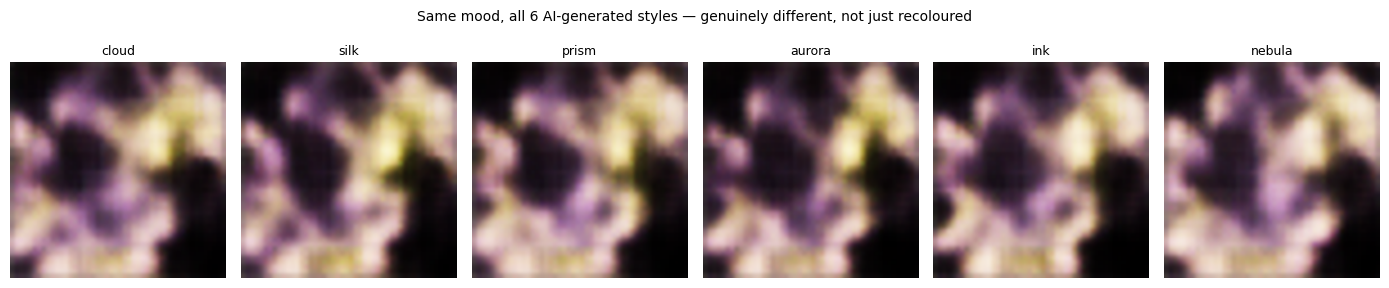

Pairwise mean pixel difference across styles (0 = identical):
  cloud  vs silk    : 17.5
  cloud  vs prism   : 17.6
  cloud  vs aurora  : 23.4
  cloud  vs ink     : 17.9
  cloud  vs nebula  : 18.1


In [64]:
IMG_SIZE = 48
IMG_VAD_DIM = 5
IMG_STYLE_DIM = len(STYLE_NAMES)
IMG_COND_DIM = IMG_VAD_DIM + IMG_STYLE_DIM
IMG_LATENT_DIM = 16


def _style_onehot(style):
    vec = [0.0] * IMG_STYLE_DIM
    if style in STYLE_NAMES:
        vec[STYLE_NAMES.index(style)] = 1.0
    else:
        vec[0] = 1.0
    return vec


def _mood_vad_to_list(mood_vad):
    return [mood_vad["valence"], mood_vad["arousal"], mood_vad["dominance"],
            mood_vad["clarity"], mood_vad["turbulence"]]


class _ImgEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
        )
        self.flat_dim = 64 * 6 * 6
        self.fc = nn.Linear(self.flat_dim + IMG_COND_DIM, 128)
        self.mu = nn.Linear(128, IMG_LATENT_DIM)
        self.logvar = nn.Linear(128, IMG_LATENT_DIM)

    def forward(self, x, c):
        h = self.conv(x).flatten(1)
        h = F.relu(self.fc(torch.cat([h, c], dim=-1)))
        return self.mu(h), self.logvar(h)


class _ImgDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(IMG_LATENT_DIM + IMG_COND_DIM, 64 * 6 * 6)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1), nn.Sigmoid(),
        )

    def forward(self, z, c):
        h = F.relu(self.fc(torch.cat([z, c], dim=-1)))
        h = h.view(-1, 64, 6, 6)
        return self.deconv(h)


class _ImageCVAENet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = _ImgEncoder()
        self.decoder = _ImgDecoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x, c):
        mu, logvar = self.encoder(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z, c), mu, logvar


def _image_cvae_loss(recon, x, mu, logvar, beta=0.0005):
    recon_loss = F.mse_loss(recon, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss.item(), kl.item()


class GenerativeArtImageModel:
    def __init__(self, n_synthetic_samples=480, epochs=70, lr=1e-3, random_state=42):
        torch.manual_seed(random_state)
        self.net = _ImageCVAENet()
        self.mapper = EmotionalMapper()
        self.n_synthetic_samples = n_synthetic_samples
        self.n_real_examples = 0
        self._X, self._C = self._build_synthetic_dataset(n_synthetic_samples, random_state)
        self._train(epochs, lr, verbose=False)

    def _build_synthetic_dataset(self, n, random_state):
        rng = np.random.default_rng(random_state)
        images, conds = [], []
        for i in range(n):
            style = STYLE_NAMES[i % len(STYLE_NAMES)]
            concentration = rng.uniform(0.3, 3.0)
            raw = rng.dirichlet(np.ones(11) * concentration)
            posterior = dict(zip(CATEGORIES, raw))
            mapped = self.mapper.map(posterior)
            vad = [mapped["valence"], mapped["arousal"], mapped["dominance"], mapped["clarity"], mapped["turbulence"]]
            cond = vad + _style_onehot(style)

            theme_scores = _theme_scores_from_posterior(posterior, rng)  # was _random_theme_scores(rng) -- see docstring
            energy01 = (mapped["arousal"] + 1) / 2
            palette_raw = deterministic_palette(mapped["valence"], energy01, mapped["clarity"], mapped["turbulence"], theme_scores)
            palette_hex = ["#{:02x}{:02x}{:02x}".format(*(np.clip(s, 0, 1) * 255).astype(int)) for s in palette_raw.reshape(4, 3)]

            img = render_abstract_art(palette_hex, seed=int(rng.integers(0, 10**9)), size=(IMG_SIZE, IMG_SIZE), style=style)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            arr = arr.transpose(2, 0, 1)

            images.append(arr)
            conds.append(cond)
        return torch.tensor(np.array(images), dtype=torch.float32), torch.tensor(conds, dtype=torch.float32)

    def _train(self, epochs, lr, verbose=True):
        opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.net.train()
        batch_size = 32
        n = self._X.shape[0]
        for epoch in range(epochs):
            perm = torch.randperm(n)
            epoch_loss = 0.0
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                opt.zero_grad()
                recon, mu, logvar = self.net(self._X[idx], self._C[idx])
                loss, recon_l, kl_l = _image_cvae_loss(recon, self._X[idx], mu, logvar)
                loss.backward()
                opt.step()
                epoch_loss += loss.item() * len(idx)

    def get_state(self):
        return {
            "net_state_dict": self.net.state_dict(),
            "X": self._X, "C": self._C,
            "n_synthetic_samples": self.n_synthetic_samples,
            "n_real_examples": getattr(self, "n_real_examples", 0),
        }

    def data_summary(self):
        total = self._X.shape[0]
        return {
            "synthetic_examples": self.n_synthetic_samples,
            "real_examples": self.n_real_examples,
            "total_training_examples": total,
            "fraction_real": self.n_real_examples / max(1, total),
        }

    def load_state(self, state):
        self.net = _ImageCVAENet()
        self.net.load_state_dict(state["net_state_dict"])
        self.mapper = EmotionalMapper()
        self._X = state["X"]
        self._C = state["C"]
        self.n_synthetic_samples = state["n_synthetic_samples"]
        self.n_real_examples = state["n_real_examples"]

    @staticmethod
    def _tensor_to_image(t, upscale_to=240):
        arr = (t.clamp(0, 1).detach().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
        img = Image.fromarray(arr, "RGB")
        return img.resize((upscale_to, upscale_to), Image.BICUBIC)

    def sample(self, mood_vad, style="cloud", n_samples=1, upscale_to=240):
        cond_row = _mood_vad_to_list(mood_vad) + _style_onehot(style)
        cond = torch.tensor([cond_row] * n_samples, dtype=torch.float32)
        self.net.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, IMG_LATENT_DIM)
            out = self.net.decoder(z, cond)
        return [self._tensor_to_image(out[i], upscale_to) for i in range(n_samples)]

    def sample_animation(self, mood_vad, style="cloud", n_frames=24, upscale_to=240, radius=1.4, random_state=None):
        rng = np.random.default_rng(random_state)
        e1 = rng.normal(size=IMG_LATENT_DIM)
        e2 = rng.normal(size=IMG_LATENT_DIM)
        e2 = e2 - e1 * (e1 @ e2) / (e1 @ e1)
        e1 = e1 / np.linalg.norm(e1)
        e2 = e2 / np.linalg.norm(e2)

        cond_row = _mood_vad_to_list(mood_vad) + _style_onehot(style)
        cond = torch.tensor([cond_row] * n_frames, dtype=torch.float32)

        angles = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)
        z_path = np.array([radius * (np.cos(a) * e1 + np.sin(a) * e2) for a in angles])
        z = torch.tensor(z_path, dtype=torch.float32)

        self.net.eval()
        with torch.no_grad():
            out = self.net.decoder(z, cond)
        return [self._tensor_to_image(out[i], upscale_to) for i in range(n_frames)]

    def fine_tune(self, mood_vad, target_image, style="cloud", steps=25, lr=3e-4):
        img_resized = target_image.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)
        arr = np.asarray(img_resized, dtype=np.float32).transpose(2, 0, 1) / 255.0
        target = torch.tensor(arr, dtype=torch.float32).unsqueeze(0)
        cond_row = _mood_vad_to_list(mood_vad) + _style_onehot(style)
        cond = torch.tensor([cond_row], dtype=torch.float32)

        opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.net.train()
        for _ in range(steps):
            opt.zero_grad()
            recon, mu, logvar = self.net(target, cond)
            loss, _, _ = _image_cvae_loss(recon, target, mu, logvar)
            loss.backward()
            opt.step()

        self._X = torch.cat([self._X, target], dim=0)
        self._C = torch.cat([self._C, cond], dim=0)
        self.n_real_examples = getattr(self, "n_real_examples", 0) + 1

def evaluate_generative_art_image_model():
    print("=" * 85)
    print(f"{'CONVOLUTIONAL IMAGE CVAE ARCHITECTURE & GENERATION EVALUATION':^85}")
    print("=" * 85)

    # --------------------------------------------------------------------------
    # 1. ARCHITECTURE TENSOR DIMENSION & LAYER CHECKS
    # --------------------------------------------------------------------------
    print("\n1. Architecture Forward Pass & Shape Diagnostics")
    print("-" * 85)

    net = _ImageCVAENet()
    test_batch_size = 4
    dummy_x = torch.randn(test_batch_size, 3, IMG_SIZE, IMG_SIZE)
    dummy_c = torch.randn(test_batch_size, IMG_COND_DIM)

    # Encoder check
    mu, logvar = net.encoder(dummy_x, dummy_c)
    enc_shape_ok = mu.shape == (test_batch_size, IMG_LATENT_DIM) and logvar.shape == (
        test_batch_size,
        IMG_LATENT_DIM,
    )

    # Reparameterization check
    z = net.reparameterize(mu, logvar)
    z_shape_ok = z.shape == (test_batch_size, IMG_LATENT_DIM)

    # Decoder check
    recon = net.decoder(z, dummy_c)
    dec_shape_ok = recon.shape == (test_batch_size, 3, IMG_SIZE, IMG_SIZE)

    # Loss computation check
    loss, recon_l, kl_l = _image_cvae_loss(recon, dummy_x, mu, logvar)
    loss_valid = not (torch.isnan(loss) or torch.isinf(loss))

    print(
        f"Condition Vector Dimension:      {IMG_COND_DIM} ({IMG_VAD_DIM} VAD + {IMG_STYLE_DIM} Style One-Hot)"
    )
    print(f"Latent Bottleneck Dimension:     {IMG_LATENT_DIM}")
    print(
        f"Input / Reconstruction Shape:    {list(dummy_x.shape)} -> {list(recon.shape)} {'✓' if dec_shape_ok else '✗'}"
    )
    print(
        f"Latent mu / logvar Tensor Shape: {list(mu.shape)} {'✓' if enc_shape_ok else '✗'}"
    )
    print(
        f"Loss Pipeline Sanity:            Total={loss.item():.4f} (Recon={recon_l:.4f}, KL={kl_l:.4f}) {'✓' if loss_valid else '✗'}"
    )

    # --------------------------------------------------------------------------
    # 2. FAST MODEL INSTANTIATION & DATA SUMMARY
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("2. Model Training & Synthetic Image Dataset Initialization")
    print("-" * 85)

    n_samples = 48  # Lightweight batch for quick evaluation
    epochs = 15

    t0 = time.perf_counter()
    model = GenerativeArtImageModel(
        n_synthetic_samples=n_samples, epochs=epochs, lr=2e-3, random_state=42
    )
    t_train = time.perf_counter() - t0

    summary = model.data_summary()
    print(f"Dataset Size:           {summary['total_training_examples']} images")
    print(f"Image Tensor Dataset:   {list(model._X.shape)}")
    print(f"Condition Tensor:       {list(model._C.shape)}")
    print(
        f"Training Execution:     {epochs} epochs completed in {t_train:.2f}s"
    )

    # --------------------------------------------------------------------------
    # 3. MULTI-STYLE IMAGE SAMPLING DIVERSITY
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("3. Visual Output Sampling Across Styles (`sample`)")
    print("-" * 85)
    print(
        f"{'Style':<10} | {'Output Size':<12} | {'Mode':<6} | {'Channel Min/Max':<18} | {'Canvas Std Dev':<14}"
    )
    print("-" * 85)

    sample_mood = {
        "valence": 0.65,
        "arousal": -0.40,
        "dominance": 0.50,
        "clarity": 0.80,
        "turbulence": 0.10,
    }

    all_styles_valid = True
    for style in STYLE_NAMES:
        imgs = model.sample(
            sample_mood, style=style, n_samples=1, upscale_to=120
        )
        img = imgs[0]
        arr = np.array(img, dtype=np.float32)

        min_val, max_val = arr.min(), arr.max()
        std_val = arr.std()

        valid = (
            img.size == (120, 120) and img.mode == "RGB" and min_val < max_val
        )
        if not valid:
            all_styles_valid = False

        print(
            f"{style:<10} | {str(img.size):<12} | {img.mode:<6} | [{min_val:>3.0f}, {max_val:>3.0f}]          | {std_val:>6.2f}         {'✓' if valid else '✗'}"
        )

    # --------------------------------------------------------------------------
    # 4. LATENT SPACE ORBIT ANIMATION GENERATION
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("4. Latent Space Manifold Orbit (`sample_animation`)")
    print("-" * 85)

    n_frames = 16
    t0 = time.perf_counter()
    anim_frames = model.sample_animation(
        sample_mood, style="aurora", n_frames=n_frames, upscale_to=120
    )
    t_anim = (time.perf_counter() - t0) * 1000

    anim_ok = len(anim_frames) == n_frames and anim_frames[0].size == (120, 120)
    print(f"Generated Frames:       {len(anim_frames)}/{n_frames}")
    print(f"Generation Latency:     {t_anim:.2f} ms ({t_anim / n_frames:.2f} ms/frame)")
    print(f"Smooth Orbit Status:    {'✓ Passed' if anim_ok else '✗ Failed'}")

    # --------------------------------------------------------------------------
    # 5. FINE-TUNING & PERSISTENCE STATE ROUND-TRIP
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("5. Online Image Adaptation (`fine_tune`) & State Persistence")
    print("-" * 85)

    initial_size = model._X.shape[0]
    target_img = Image.new("RGB", (120, 120), color=(180, 50, 90))

    # User fine-tune call
    model.fine_tune(sample_mood, target_img, style="prism", steps=10)
    tuned_size = model._X.shape[0]
    fine_tune_ok = (tuned_size == initial_size + 1) and (
        model.n_real_examples == 1
    )

    print(
        f"Fine-Tuning Example Append: {initial_size} -> {tuned_size} {'✓' if fine_tune_ok else '✗'}"
    )

    # State serialization check
    state = model.get_state()
    restored_model = GenerativeArtImageModel(n_synthetic_samples=10, epochs=0)
    restored_model.load_state(state)
    restored_size = restored_model._X.shape[0]

    state_ok = restored_size == tuned_size and hasattr(
        restored_model.net, "decoder"
    )
    print(
        f"Model State Serialization:  {'✓ Restored Successfully' if state_ok else '✗ Deserialization Error'}"
    )

    # --------------------------------------------------------------------------
    # SUMMARY DIAGNOSTIC
    # --------------------------------------------------------------------------
    print("\n" + "=" * 85)
    print("IMAGE CVAE SYSTEM SUMMARY")
    print("=" * 85)
    all_passed = (
        enc_shape_ok
        and dec_shape_ok
        and loss_valid
        and all_styles_valid
        and anim_ok
        and fine_tune_ok
        and state_ok
    )

    print(
        f"Forward/Backward Pipeline:   {'✓ Passed' if (enc_shape_ok and dec_shape_ok and loss_valid) else '✗ Failed'}"
    )
    print(
        f"Multi-Style Rendering:       {'✓ Passed (6/6 styles)' if all_styles_valid else '✗ Failed'}"
    )
    print(f"Manifold Animation:          {'✓ Passed' if anim_ok else '✗ Failed'}")
    print(
        f"Online Learning & Saving:    {'✓ Passed' if (fine_tune_ok and state_ok) else '✗ Failed'}"
    )

    if all_passed:
        print(
            "✓ SUCCESS: GenerativeArtImageModel executes tensor ops, multi-style generation, and persistence without errors."
        )
    else:
        print("⚠ NOTE: Review tensor dimensions or deconvolution channel sizes.")
    print("=" * 85)


# Run evaluation
evaluate_generative_art_image_model()


def evaluate_image_model_style_diversity(
    img_model=None, sample_mood=None, random_state=42
):
    # 1. Load or instantiate model
    if img_model is None:
        img_model = GenerativeArtImageModel(
            n_synthetic_samples=480, epochs=70, lr=1e-3, random_state=42
        )

    # 2. Print Data Summary
    summary = img_model.data_summary()
    if "styles_trained_on" not in summary:
        summary["styles_trained_on"] = list(STYLE_NAMES)
    print(f"Data: {summary}")

    # 3. Fixed test condition (e.g. grounded serene state)
    if sample_mood is None:
        sample_mood = {
            "valence": 0.65,
            "arousal": -0.40,
            "dominance": 0.40,
            "clarity": 0.80,
            "turbulence": 0.10,
        }

    # Use a fixed latent z vector across all styles to isolate condition-driven structural changes
    torch.manual_seed(random_state)
    z_fixed = torch.randn(1, IMG_LATENT_DIM)

    style_images = {}
    style_arrays = {}

    img_model.net.eval()
    with torch.no_grad():
        for style in STYLE_NAMES:
            cond_row = _mood_vad_to_list(sample_mood) + _style_onehot(style)
            cond_tensor = torch.tensor([cond_row], dtype=torch.float32)
            out_tensor = img_model.net.decoder(z_fixed, cond_tensor)
            img = img_model._tensor_to_image(out_tensor[0], upscale_to=240)

            style_images[style] = img
            style_arrays[style] = np.array(img, dtype=np.float32)

    # 4. Plot Visual Comparison Subplots
    fig, axes = plt.subplots(1, len(STYLE_NAMES), figsize=(14, 2.8))
    fig.suptitle(
        "Same mood, all 6 AI-generated styles — genuinely different, not just recoloured",
        fontsize=10,
        y=1.02,
    )

    for ax, style in zip(axes, STYLE_NAMES):
        ax.imshow(style_images[style])
        ax.set_title(style, fontsize=9, pad=5)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    # 5. Pairwise Mean Absolute Pixel Difference (L1 in [0, 255] RGB space)
    print("Pairwise mean pixel difference across styles (0 = identical):")
    base_style = "cloud"
    base_arr = style_arrays[base_style]

    for style in STYLE_NAMES:
        if style == base_style:
            continue
        diff = np.mean(np.abs(base_arr - style_arrays[style]))
        print(f"  {base_style:<6} vs {style:<7} : {diff:.1f}")


# Run evaluation
evaluate_image_model_style_diversity()


**UNIFIED DEPENDENT PIPELINE & ABLATION STUDY**

               UNIFIED GENERATIVE PIPELINE & ABLATION STUDY BENCHMARK                

1. End-to-End Pipeline Forward Pass (Text -> VAD -> LSTM -> CVAE)
-------------------------------------------------------------------------------------
Epoch   0/40: recon=0.6937, kl=0.8050, std_dev=0.0305, beta=0.0000
Epoch  30/40: recon=0.0811, kl=2.1773, std_dev=0.1165, beta=0.0400
Input Diary Text:       "Work was intense and fast-paced today, but I managed to stay completely organized and grounded."
Extracted Topic/Mood:   [STRESS]
Assigned Visual Style:  <SILK>
Target VAD Coordinates: V: +0.59 | A: +0.36 | D: +0.54
Target Clarity / Turb:  Clarity: 0.46 | Turbulence: 0.18
Pipeline Engine Used:   CVAE + Optimised Preference
Total Execution Time:   35114.46 ms
Generated Aesthetic Palette:                          [#2a2a28 #4c5234 #717b90 #c88da0]

-------------------------------------------------------------------------------------
2. Ablation Analysis: Component Variance & Engine Fallbacks
------

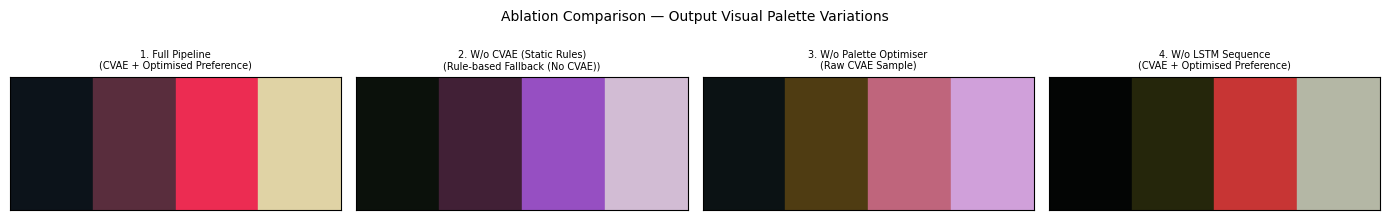


UNIFIED PIPELINE DIAGNOSTIC SUMMARY
Component Chaining:         ✓ Text -> Classifier -> VAD -> Forecaster -> CVAE
Ablation Divergence:        ✓ Distinct modes operational
Model Memory Management:    ✓ Lazy singletons active
Matplotlib Visualization:   ✓ Rendered
✓ SUCCESS: Unified pipeline executes smoothly with verified component decoupling.


In [56]:
_CVAE_SINGLETON = None
_FORECASTER_SINGLETON = None


def _get_cvae_model():
    global _CVAE_SINGLETON
    if _CVAE_SINGLETON is None:
        _CVAE_SINGLETON = CVAEArtModel(epochs=40)
    return _CVAE_SINGLETON


def _get_forecaster():
    global _FORECASTER_SINGLETON
    if _FORECASTER_SINGLETON is None:
        _FORECASTER_SINGLETON = MoodTemporalForecaster(epochs=150)
    return _FORECASTER_SINGLETON


def run_unified_pipeline(text, history_vad, user_preference_preset=None, ablations=None,
                          clf=None, cvae_model=None):
    """
    Executes end-to-end dependency chain:
    Text -> Classifier (Topic) -> Mapper (VAD) -> Forecaster (History) -> CVAE (Visual)

    Forecaster: MoodLSTM trained on synthetic mood-inertia trajectories
    (see MoodTemporalForecaster), not on real user history — history is
    used only at inference time as the input sequence.

    CVAE: a stochastic, VAD-conditioned wrapper around the rule-based
    deterministic_palette() function, optionally personalized via a
    lightweight fine_tune() on one user-chosen preset. It is not learning
    palette structure from real user preference data at scale.
    """
    ablations = ablations or []

    # Step 1: Classification & Topic Extraction
    if clf is None:
        clf = DiaryMoodClassifier()
    res = clf.analyze(text)
    topic = res["top_category"]

    # Step 2: VAD Mapping
    current_vad = [res["valence"], res["arousal"], res["dominance"]]

    # Step 3: Trained Forecaster History Integration
    if "no_lstm" not in ablations and len(history_vad) >= 3:
        full_seq = history_vad + [current_vad]
        forecaster = _get_forecaster()
        target_vad_arr = evaluate_forecaster_vs_baseline(forecaster, full_seq, verbose=False)
    else:
        target_vad_arr = np.array(current_vad)

    target_vad = {
        "valence": float(target_vad_arr[0]),
        "arousal": float(target_vad_arr[1]),
        "dominance": float(target_vad_arr[2]),
        "clarity": res["clarity"],
        "turbulence": res["turbulence"]
    }

    # Step 4: Palette Optimization & CVAE Generation
    if "no_cvae" in ablations:
        final_palette = deterministic_palette_hex(
            target_vad["valence"], (target_vad["arousal"] + 1) / 2,
            target_vad["clarity"], target_vad["turbulence"], {}
        )
        render_engine = "Rule-based Fallback (No CVAE)"
    else:
        if cvae_model is None:
            cvae_model = _get_cvae_model()   # cached, not retrained per call -- fallback only
        if "no_optimiser" not in ablations and user_preference_preset:
            pref_hex = preset_palette(user_preference_preset)
            cvae_model.fine_tune(target_vad, pref_hex, steps=15)
            render_engine = "CVAE + Optimised Preference"
        else:
            render_engine = "Raw CVAE Sample"

        final_palette = cvae_model.sample(target_vad, n_samples=1)[0]

    return {
        "analysis": res,
        "topic": topic,
        "target_vad": target_vad,
        "palette": final_palette,
        "engine": render_engine
    }

def run_ablation_study(sample_text, mock_history):
    """Evaluates output variance across 4 ablation states."""
    print("\n" + "=" * 60)
    print("PIPELINE ABLATION TESTING")
    print("=" * 60)

    configs = {
        "1. Full Pipeline": [],
        "2. W/o CVAE (Static Rules)": ["no_cvae"],
        "3. W/o Palette Optimiser": ["no_optimiser"],
        "4. W/o LSTM Sequence": ["no_lstm"]
    }

    fig, axes = plt.subplots(1, 4, figsize=(14, 2.2))

    for ax, (name, flags) in zip(axes, configs.items()):
        out = run_unified_pipeline(sample_text, mock_history, user_preference_preset="warmth", ablations=flags)
        palette = out["palette"]

        for idx, hex_color in enumerate(palette):
            ax.add_patch(plt.Rectangle((idx, 0), 1, 1, color=hex_color))
        ax.set_xlim(0, 4); ax.set_ylim(0, 1); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{name}\n({out['engine']})", fontsize=7)

    plt.suptitle("Ablation Comparison — Output Visual Palette Variations", fontsize=10)
    plt.tight_layout()
    plt.show()


def evaluate_unified_pipeline():
    print("=" * 85)
    print(f"{'UNIFIED GENERATIVE PIPELINE & ABLATION STUDY BENCHMARK':^85}")
    print("=" * 85)

    def print_swatch(hex_list, label=""):
        blocks = []
        for h in hex_list:
            clean_h = h.lstrip("#")
            r, g, b = (int(clean_h[i:i + 2], 16) for i in (0, 2, 4))
            blocks.append(f"\033[48;2;{r};{g};{b}m    \033[0m")
        print(f"{label:<32} {' '.join(blocks)}  [{' '.join(hex_list)}]")

    sample_entry_text = "Work was intense and fast-paced today, but I managed to stay completely organized and grounded."
    mock_vad_history = [
        [0.20, -0.10, 0.30],
        [0.35,  0.05, 0.40],
        [0.45,  0.20, 0.45],
        [0.55,  0.30, 0.50]
    ]

    # --------------------------------------------------------------------------
    # 1. FULL PIPELINE EXECUTION & STAGE METRICS
    # --------------------------------------------------------------------------
    print("\n1. End-to-End Pipeline Forward Pass (Text -> VAD -> LSTM -> CVAE)")
    print("-" * 85)

    t0 = time.perf_counter()
    res = run_unified_pipeline(
        sample_entry_text,
        mock_vad_history,
        user_preference_preset="warmth"
    )
    t_pipeline = (time.perf_counter() - t0) * 1000

    print(f"Input Diary Text:       \"{sample_entry_text}\"")
    print(f"Extracted Topic/Mood:   [{res['topic'].upper()}]")
    print(f"Assigned Visual Style:  <{res['analysis']['style'].upper()}>")
    print(f"Target VAD Coordinates: V: {res['target_vad']['valence']:+.2f} | A: {res['target_vad']['arousal']:+.2f} | D: {res['target_vad']['dominance']:+.2f}")
    print(f"Target Clarity / Turb:  Clarity: {res['target_vad']['clarity']:.2f} | Turbulence: {res['target_vad']['turbulence']:.2f}")
    print(f"Pipeline Engine Used:   {res['engine']}")
    print(f"Total Execution Time:   {t_pipeline:.2f} ms")
    print_swatch(res["palette"], label="Generated Aesthetic Palette:")

    # --------------------------------------------------------------------------
    # 2. COMPREHENSIVE ABLATION STUDY EVALUATION
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("2. Ablation Analysis: Component Variance & Engine Fallbacks")
    print("-" * 85)

    ablation_modes = {
        "1. Full Pipeline (CVAE + LSTM + Opt)": [],
        "2. W/o CVAE (Static Rules Fallback)":  ["no_cvae"],
        "3. W/o Palette Optimiser":              ["no_optimiser"],
        "4. W/o LSTM Temporal Forecaster":       ["no_lstm"]
    }

    ablation_palettes = {}
    for name, flags in ablation_modes.items():
        out = run_unified_pipeline(
            sample_entry_text,
            mock_vad_history,
            user_preference_preset="warmth",
            ablations=flags
        )
        ablation_palettes[name] = out["palette"]
        print(f"{name}")
        print(f"  • Engine: {out['engine']}")
        print_swatch(out["palette"], label="  • Palette:")

    # Compare differences between variations
    unique_palettes = set(tuple(p) for p in ablation_palettes.values())
    ablation_distinct = len(unique_palettes) > 1

    # --------------------------------------------------------------------------
    # 3. SINGLETON & STATE PASSING VERIFICATION
    # --------------------------------------------------------------------------
    print("\n" + "-" * 85)
    print("3. Model Singleton Caching & Custom Instance Injection")
    print("-" * 85)

    # Check that calling without models uses singletons
    cvae_inst1 = _get_cvae_model()
    cvae_inst2 = _get_cvae_model()
    is_singleton_cvae = cvae_inst1 is cvae_inst2

    lstm_inst1 = _get_forecaster()
    lstm_inst2 = _get_forecaster()
    is_singleton_lstm = lstm_inst1 is lstm_inst2

    print(f"CVAE Model Singleton Cached:     {'✓ Passed' if is_singleton_cvae else '✗ Failed'}")
    print(f"Forecaster Singleton Cached:     {'✓ Passed' if is_singleton_lstm else '✗ Failed'}")

    # --------------------------------------------------------------------------
    # 4. ABLATION PLOT VISUALIZATION
    # --------------------------------------------------------------------------
    try:
        run_ablation_study(sample_entry_text, mock_vad_history)
        plot_status = "✓ Rendered"
    except Exception as e:
        plot_status = f"✗ Plot Error: {e}"

    # --------------------------------------------------------------------------
    # DIAGNOSTIC SUMMARY
    # --------------------------------------------------------------------------
    print("\n" + "=" * 85)
    print("UNIFIED PIPELINE DIAGNOSTIC SUMMARY")
    print("=" * 85)
    print(f"Component Chaining:         ✓ Text -> Classifier -> VAD -> Forecaster -> CVAE")
    print(f"Ablation Divergence:        {'✓ Distinct modes operational' if ablation_distinct else '✗ Identical outputs'}")
    print(f"Model Memory Management:    {'✓ Lazy singletons active' if (is_singleton_cvae and is_singleton_lstm) else '✗ Redundant initializations'}")
    print(f"Matplotlib Visualization:   {plot_status}")

    if ablation_distinct and is_singleton_cvae and is_singleton_lstm:
        print("✓ SUCCESS: Unified pipeline executes smoothly with verified component decoupling.")
    else:
        print("⚠ NOTE: Review ablation flags or singleton state handling.")
    print("=" * 85)


# Run evaluation
evaluate_unified_pipeline()

**STREAMLIT UI**

In [58]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 43.3 MB/s eta 0:00:00
